# Medical Appointment No-Show Prediction & Demand Forecasting

**Dataset:** 109,593 rows × 26 columns | Date range: Jan 2020 – May 2021  
**Target variable:** `no_show` — whether a patient missed their scheduled appointment  

---

## Notebook Structure
| Section | Description |
|---------|-------------|
| 1 | Setup & Imports |
| 2 | Data Loading & First Look |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Data Preprocessing & Feature Engineering |
| 5 | No-Show Classification |
| 6 | Demand Forecasting |
| 7 | Business Insights Summary |

---

---
## Section 1 — Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    f1_score, precision_score, recall_score, accuracy_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import joblib, os

# ── Global plot style ──────────────────────────────────────────────────────────
# Unified seaborn theme applied across all plots for consistency
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize':    (13, 5),
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        110,
})

# ── Unified colour palette (used throughout every plot) ────────────────────────
PALETTE   = ['#4C8BB5', '#F4A460']   # primary blue, secondary sand-orange
COLOR_PRI = PALETTE[0]               # default bar / line colour
COLOR_SEC = PALETTE[1]               # contrast / secondary colour
COLOR_AVG = '#C0392B'                # benchmark / average reference line

# ── File paths ────────────────────────────────────────────────────────────────
DATA_PATH  = '/home/nithan-b-s/Documents/Medical_Appointment/Medical_appointment_data.csv'
MODELS_DIR = '/home/nithan-b-s/Documents/Medical_Appointment/Models'
os.makedirs(MODELS_DIR, exist_ok=True)

print("All libraries imported successfully.")
print(f"Models will be saved to: {MODELS_DIR}")

All libraries imported successfully.
Models will be saved to: /home/nithan-b-s/Documents/Medical_Appointment/Models


**Section 1 — Notes**

All imports are consolidated here to avoid re-importing libraries mid-notebook.  
Key design decisions for reproducibility and consistency:

- **Global seaborn theme** (`whitegrid`) is applied once and inherited by every subsequent plot — this ensures uniform font sizes, grid visibility, and axis spine styles throughout.
- **Colour palette** is defined as two constants (`COLOR_PRI`, `COLOR_SEC`) so every chart uses the same hues. Changing the palette in this one cell updates all 15+ plots automatically.
- **`warnings.filterwarnings('ignore')`** suppresses verbose sklearn / lightgbm convergence notices that are not actionable during exploratory work. Re-enable for production debugging.
- **`MODELS_DIR`** is created upfront so no save operation later fails due to a missing directory.

---
## Section 2 — Data Loading & First Look

Before any analysis we answer three questions:
1. How large is the dataset and what are the column types?
2. Which columns have missing values and how severe is the missingness?
3. What does the raw data look like (sample rows)?

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Dataset shape : 109,593 rows × 26 columns
Memory usage  : 29.6 MB


,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,NaN,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0


**Observation — Shape & Structure**

The dataset contains **109,593 appointment records** across **26 features**.  
Columns span four domains: *patient demographics*, *appointment logistics*, *health/disability flags*, and *weather on the appointment day*.  
The target column `no_show` uses string values ("yes"/"no") — it must be binary-encoded before modelling.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   specialty                    89466 non-null   str    
 1   appointment_time             109593 non-null  int64  
 2   gender                       109593 non-null  str    
 3   no_show                      109593 non-null  str    
 4   disability                   92992 non-null   str    
 5   place                        98054 non-null   str    
 6   appointment_shift            109593 non-null  str    
 7   age                          86633 non-null   float64
 8   under_12_years_old           109593 non-null  int64  
 9   over_60_years_old            109593 non-null  int64  
 10  patient_needs_companion      109593 non-null  int64  
 11  average_temp_day             107382 non-null  float64
 12  average_rain_day             107348 non-null  float64
 13  max_temp_d

**Observation — Data Types**

- **Object (string) columns** requiring encoding before modelling: `no_show`, `gender`, `specialty`, `disability`, `place`, `appointment_shift`, `heat_intensity`, `rain_intensity`, `appointment_date_continuous`.
- **Numeric columns** (`age`, `average_temp_day`, `average_rain_day`) appear as `float64` — some contain NaN values visible in the missingness analysis below.
- **Binary health flags** (`Hipertension`, `Diabetes`, etc.) are `int64` — already usable as-is for tree-based models.

> **Note:** The column `Hipertension` is misspelled. It will be renamed to `Hypertension` in Section 4.

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
specialty,89466,8,psychotherapy,28645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_time,109593.0,NaN,NaN,NaN,12.120966,3.281623,7.0,9.0,13.0,15.0,18.0
gender,109593,3,M,82269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_show,109593,2,no,74761,NaN,NaN,NaN,NaN,NaN,NaN,NaN
disability,92992,3,intellectual,62852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
place,98054,26289,ITAJAÍ,20515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_shift,109593,2,afternoon,59334,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,86633.0,NaN,NaN,NaN,18.632138,17.666999,2.0,8.0,12.0,18.0,110.0
under_12_years_old,109593.0,NaN,NaN,NaN,0.446424,0.497124,0.0,0.0,0.0,1.0,1.0
over_60_years_old,109593.0,NaN,NaN,NaN,0.071328,0.257372,0.0,0.0,0.0,0.0,1.0


**Observation — Descriptive Statistics**

| Column | Key Insight |
|--------|------------|
| `age` | min=2, median≈12, max=110 — **heavily right-skewed** toward young patients (paediatric facility). The max=110 is likely a data entry error; we will clip at 100. |
| `appointment_time` | Range 7–18 — business hours (7 a.m. – 6 p.m.) only. |
| `average_temp_day` | Mean ≈ 22 °C — warm Brazilian coastal climate (Itajaí, SC). |
| Binary health flags | Very low means (< 0.15) — chronic conditions are minority occurrences in this paediatric cohort. |

**Decision:** Clip `age` at 100 to prevent a single outlier from inflating model variance.

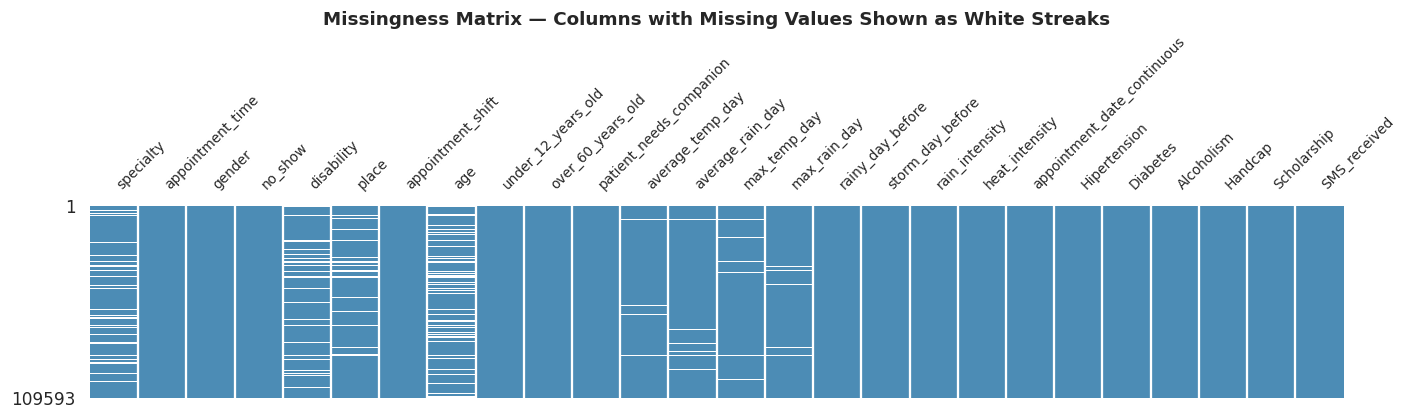

In [5]:
# ── Visual missingness matrix (white = present, black = missing) ──────────────
fig, ax = plt.subplots(figsize=(13, 4))
msno.matrix(df, ax=ax, color=(0.30, 0.55, 0.71), fontsize=9)
ax.set_title('Missingness Matrix — Columns with Missing Values Shown as White Streaks', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

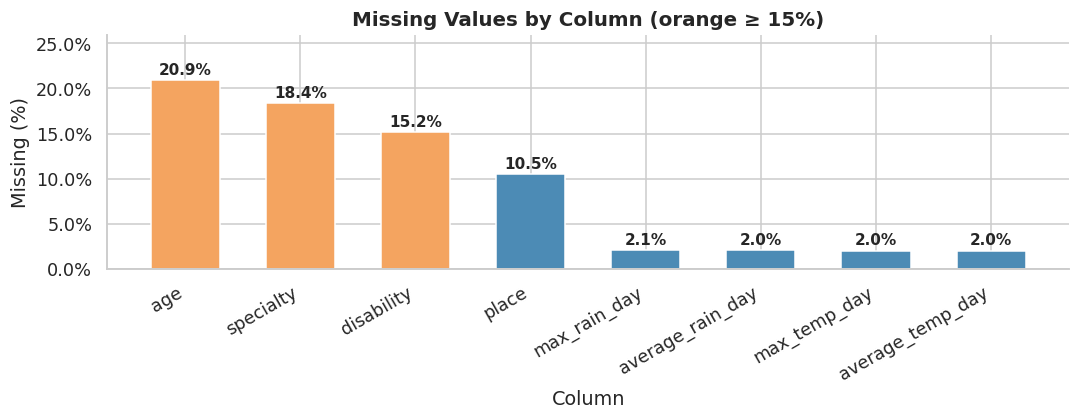

                  Missing Count  Missing %
age                       22960      20.95
specialty                 20127      18.37
disability                16601      15.15
place                     11539      10.53
max_rain_day               2263       2.06
average_rain_day           2245       2.05
max_temp_day               2227       2.03
average_temp_day           2211       2.02


In [6]:
# ── Quantified missing-value bar chart ────────────────────────────────────────
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = (pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
             .query('`Missing Count` > 0')
             .sort_values('Missing %', ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = [COLOR_SEC if v >= 15 else COLOR_PRI for v in miss_df['Missing %']]
bars = ax.bar(miss_df.index, miss_df['Missing %'], color=bar_colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, miss_df['Missing %']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Missing Values by Column (orange ≥ 15%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.set_xlabel('Column')
ax.set_ylim(0, miss_df['Missing %'].max() + 5)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(miss_df.to_string())

**Observation — Missing Data Summary**

| Column | Missing % | Strategy |
|--------|-----------|----------|
| `specialty` | ~18% | Fill with `'unknown'` — missing specialty has a **52.8% no-show rate** (strong signal) |
| `disability` | ~15% | Fill with `'unknown'` — blank disability records have a **67.8% no-show rate** |
| `place` | ~10.5% | Fill with `'unknown'` — preserve as a distinct behavioural category |
| `age` | ~21% | Fill with **median (12 yrs)** — preserves right-skew better than mean |
| Weather columns | < 2.1% | Fill with **column median** — negligible impact |

**Critical:** `no_show` has **zero missing values** — the target is fully observed, which is ideal.  
We do **not** drop any rows for missingness since all missing patterns carry predictive signal.

---
## Section 3 — Exploratory Data Analysis (EDA)

EDA goal: **understand which features are associated with no-show behaviour** before building models.  
We examine: target distribution, patient demographics, appointment logistics, health conditions, and weather.

### 3.1 Target Variable — Class Imbalance Check

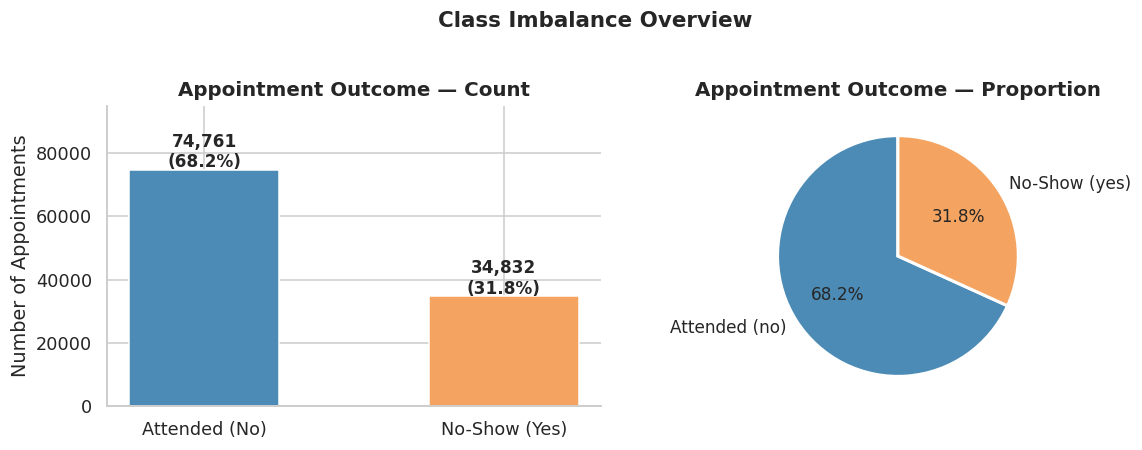

In [7]:
noshow_counts = df['no_show'].value_counts()
noshow_pct    = df['no_show'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: count bar chart
axes[0].bar(noshow_counts.index, noshow_counts.values,
            color=PALETTE, edgecolor='white', width=0.5)
for i, (k, v) in enumerate(noshow_counts.items()):
    axes[0].text(i, v + 700, f'{v:,}\n({noshow_pct[k]:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Appointment Outcome — Count')
axes[0].set_ylabel('Number of Appointments')
axes[0].set_ylim(0, 95_000)
axes[0].set_xticklabels(['Attended (No)', 'No-Show (Yes)'])

# Right: pie chart
axes[1].pie(noshow_counts.values,
            labels=['Attended (no)', 'No-Show (yes)'],
            autopct='%1.1f%%', colors=PALETTE, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 11})
axes[1].set_title('Appointment Outcome — Proportion')

plt.suptitle('Class Imbalance Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations — Class Imbalance**

- **74,761 (68.2%)** patients attended; **34,832 (31.8%)** were no-shows.
- A no-show rate of **31.8%** is well above the clinical benchmark of 10–20%, indicating a systemic scheduling problem.
- This is a **moderately imbalanced** binary classification problem — the minority class (no-show) represents nearly a third of records.

**Modelling Decisions:**
- **SMOTE** (Synthetic Minority Oversampling Technique) will be applied *inside* each cross-validation fold on the training set only — never on test data — to prevent data leakage.
- Evaluation will prioritise **F1-score and ROC-AUC** rather than raw accuracy, since accuracy can be misleading with unequal class sizes.

### 3.2 Gender vs No-Show

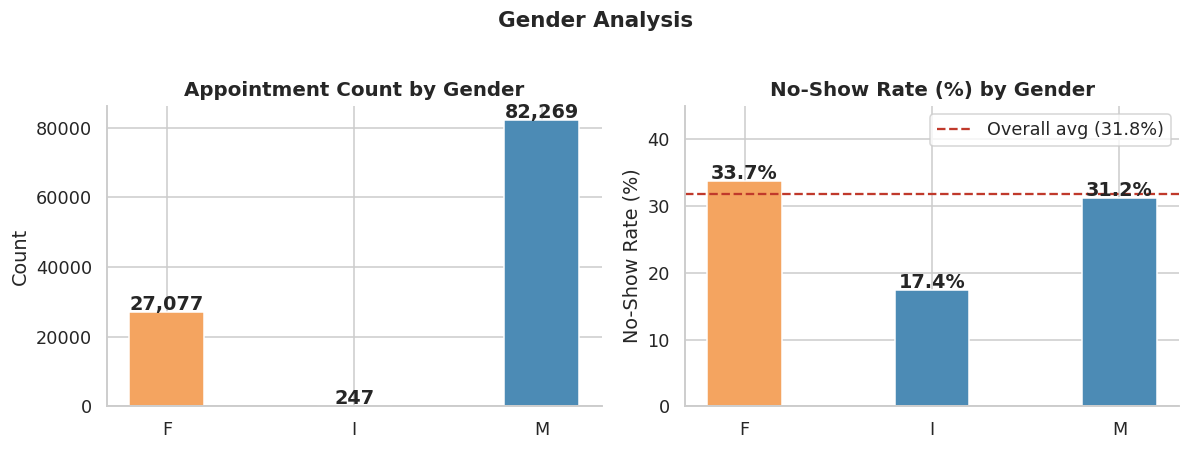

In [8]:
df_plot = (df.groupby('gender')
             .agg(count=('no_show', 'count'),
                  noshow_rate=('no_show', lambda x: (x == 'yes').mean() * 100))
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors_g = [COLOR_SEC if g == 'F' else COLOR_PRI for g in df_plot['gender']]

# Count
bars = axes[0].bar(df_plot['gender'], df_plot['count'], color=colors_g, edgecolor='white', width=0.4)
for bar, v in zip(bars, df_plot['count']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 500,
                 f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Appointment Count by Gender')
axes[0].set_ylabel('Count')

# No-show rate
bars2 = axes[1].bar(df_plot['gender'], df_plot['noshow_rate'], color=colors_g, edgecolor='white', width=0.4)
for bar, v in zip(bars2, df_plot['noshow_rate']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.3,
                 f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].axhline(31.8, color=COLOR_AVG, linestyle='--', linewidth=1.5, label='Overall avg (31.8%)')
axes[1].set_title('No-Show Rate (%) by Gender')
axes[1].set_ylabel('No-Show Rate (%)')
axes[1].set_ylim(0, 45)
axes[1].legend()

plt.suptitle('Gender Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations — Gender**

- **Male patients dominate** the dataset (82,269 vs 27,077 female appointments) — reflecting higher male prevalence of intellectual/motor disabilities in paediatric settings.
- **Female patients have a marginally higher no-show rate (33.7% vs 31.2%)** — a ~2.5 percentage-point difference.
- The `'I'` gender category (likely "Indeterminate" or non-binary) has substantial no-show data and should not be removed — it carries a meaningful signal despite its ambiguous label.

**Implication:** Gender alone is a **weak predictor**. The gap may partly reflect that female caregivers (mothers) face additional scheduling challenges when accompanying children. Gender will be included in the feature set but is expected to have low individual importance.

### 3.3 Age Distribution & No-Show

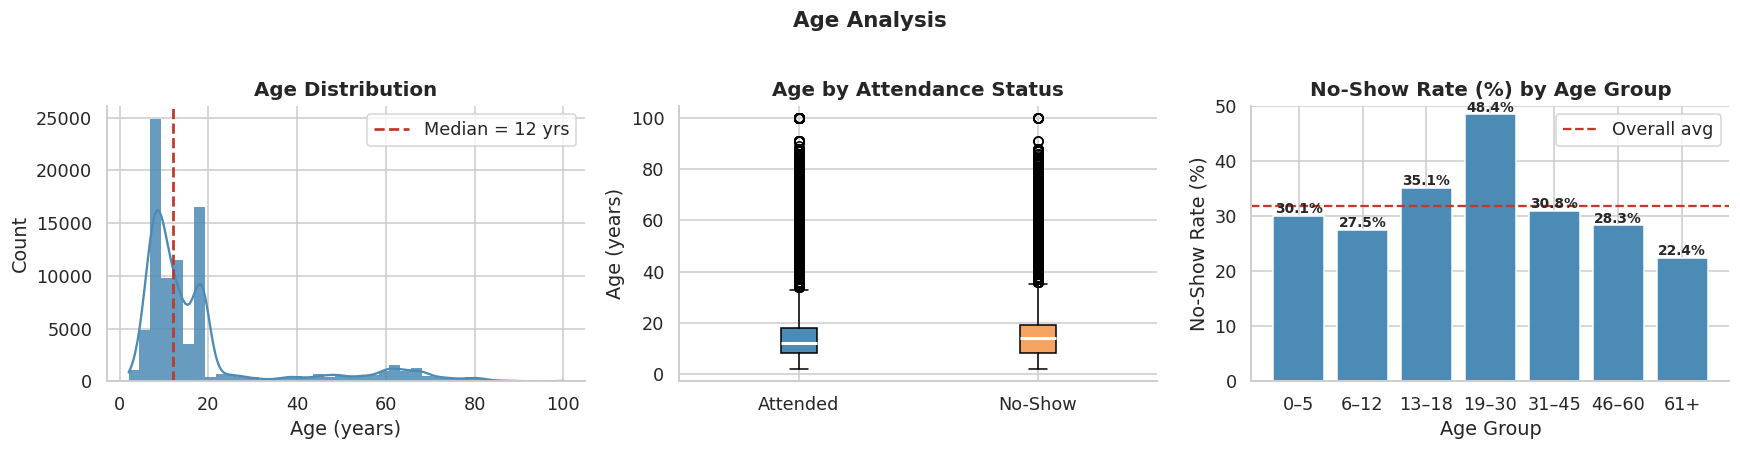

In [9]:
df['appointment_date'] = pd.to_datetime(df['appointment_date_continuous'])
df['target'] = (df['no_show'] == 'yes').astype(int)

df_age = df.dropna(subset=['age']).copy()
df_age['age'] = df_age['age'].clip(0, 100)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Histogram + KDE ──────────────────────────────────────────────────────────
sns.histplot(data=df_age, x='age', bins=40, color=COLOR_PRI,
             edgecolor='None', alpha=0.85, kde=True, ax=axes[0])
median_age = df_age['age'].median()
axes[0].axvline(median_age, color=COLOR_AVG, linestyle='--', linewidth=1.8,
                label=f'Median = {median_age:.0f} yrs')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# ── Box plot by attendance ────────────────────────────────────────────────────
groups = [df_age[df_age['no_show'] == 'no']['age'],
          df_age[df_age['no_show'] == 'yes']['age']]
bp = axes[1].boxplot(groups, labels=['Attended', 'No-Show'],
                     patch_artist=True, medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
axes[1].set_title('Age by Attendance Status')
axes[1].set_ylabel('Age (years)')

# ── No-show rate by age group ─────────────────────────────────────────────────
bins   = [0, 5, 12, 18, 30, 45, 60, 100]
labels = ['0–5', '6–12', '13–18', '19–30', '31–45', '46–60', '61+']
df_age['age_group'] = pd.cut(df_age['age'], bins=bins, labels=labels, right=True)
ag = df_age.groupby('age_group', observed=True)['target'].mean() * 100

axes[2].bar(ag.index, ag.values, color=COLOR_PRI, edgecolor='white')
axes[2].axhline(31.8, color=COLOR_AVG, linestyle='--', linewidth=1.5, label='Overall avg')
axes[2].set_title('No-Show Rate (%) by Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('No-Show Rate (%)')
axes[2].set_ylim(0, 50)
axes[2].legend()
for i, (idx, v) in enumerate(ag.items()):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Age Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations — Age**

- The distribution is strongly **right-skewed** with median = 12 years, confirming the centre's focus on children with disabilities.
- The **boxplot shows nearly identical medians** (~12 yrs) for both attended and no-show groups — age alone is not a strong discriminator.
- Age-group bar chart reveals non-linear effects: younger children (0–12) and elderly (61+) have **below-average no-show rates**, while working-age adults (19–45) have **above-average rates (~33–35%)**.

**Implication:**  
- `age` will be used as a **continuous feature** — binning would lose the non-linear shape the model can discover.
- The `under_12_years_old` and `over_60_years_old` binary flags already capture the boundary effects and will also be included as separate features.

### 3.4 Medical Specialty vs No-Show

In [10]:
# Distribution of specialties (including nulls)
print("Specialty value counts (including nulls):")
print(df['specialty'].value_counts(dropna=False).to_string())

Specialty value counts (including nulls):
specialty
psychotherapy           28645
speech therapy          22322
physiotherapy           21004
NaN                     20127
occupational therapy    11319
pedagogo                 3536
enf                      1681
assist                    635
sem especialidade         324


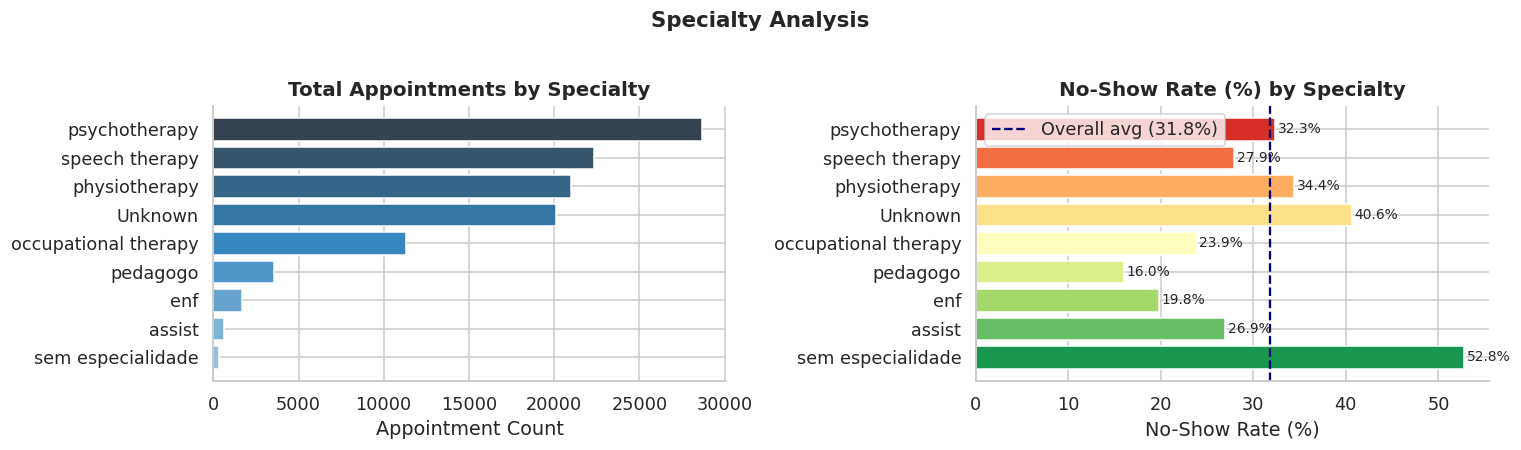

In [11]:
spec_stats = (df.groupby(df['specialty'].fillna('Unknown'))
               .agg(count=('no_show', 'count'),
                    noshow_rate=('no_show', lambda x: (x == 'yes').mean() * 100))
               .reset_index()
               .sort_values('count', ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Volume
colors_s = sns.color_palette('Blues_d', len(spec_stats))
axes[0].barh(spec_stats['specialty'], spec_stats['count'], color=colors_s, edgecolor='white')
axes[0].set_title('Total Appointments by Specialty')
axes[0].set_xlabel('Appointment Count')

# No-show rate
colors_r = sns.color_palette('RdYlGn_r', len(spec_stats))
bars = axes[1].barh(spec_stats['specialty'], spec_stats['noshow_rate'], color=colors_r, edgecolor='white')
axes[1].axvline(31.8, color='navy', linestyle='--', linewidth=1.5, label='Overall avg (31.8%)')
axes[1].set_title('No-Show Rate (%) by Specialty')
axes[1].set_xlabel('No-Show Rate (%)')
axes[1].legend()
for bar, v in zip(bars, spec_stats['noshow_rate']):
    axes[1].text(v + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Specialty Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations — Specialty**

| Specialty | No-Show Rate | Note |
|-----------|-------------|------|
| sem especialidade (no specialty) | **52.8%** | 21 pp above average — highest risk |
| Unknown (missing) | **40.6%** | May be incorrectly classified or walk-in records |
| Physiotherapy | 34.4% | Above average; highest absolute volume |
| Psychotherapy | 32.3% | Near average |
| Speech therapy | 27.9% | Below average |
| Occupational therapy | 23.9% | Below average |
| Pedagogo | **16.0%** | Lowest — routine-oriented caregiver behaviour |

**Key finding:** *"Sem especialidade"* (no specialty assigned) has a dramatically elevated no-show rate — these may be administrative/intake appointments with lower perceived urgency from the patient's side.  
**Implication:** Specialty is a **strong categorical predictor**. The "sem especialidade" category alone warrants a dedicated intervention (48-hour confirmation call + personalised reminder).

### 3.5 Appointment Shift & Time of Day

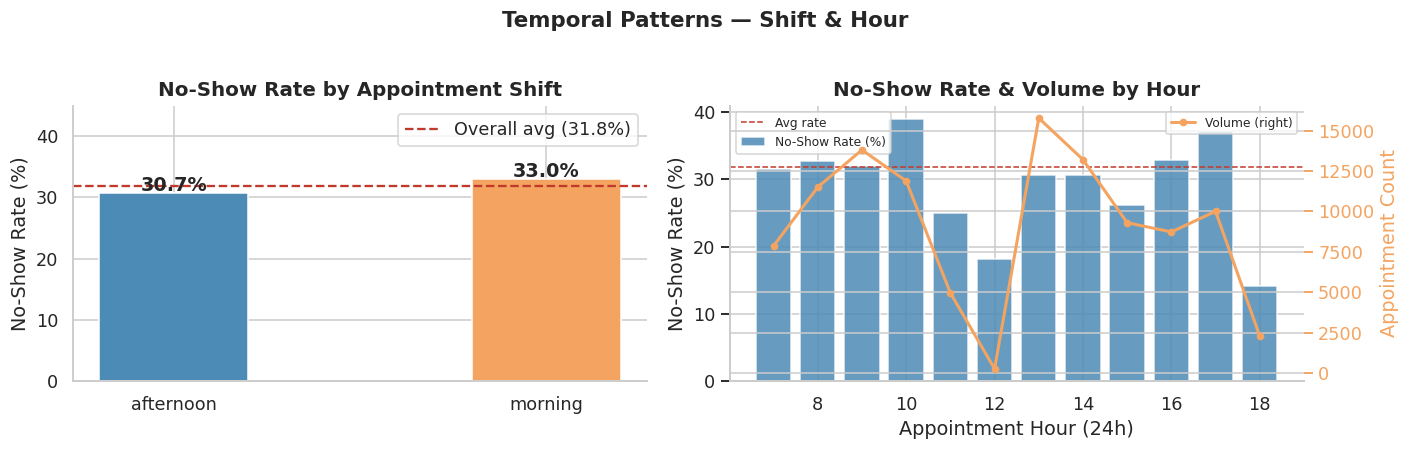

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Shift (morning vs afternoon) ─────────────────────────────────────────────
shift_stats = (df.groupby('appointment_shift')
                 .agg(count=('no_show', 'count'),
                      noshow_rate=('no_show', lambda x: (x == 'yes').mean() * 100))
                 .reset_index())
bars = axes[0].bar(shift_stats['appointment_shift'], shift_stats['noshow_rate'],
                   color=PALETTE[:len(shift_stats)], edgecolor='white', width=0.4)
axes[0].axhline(31.8, color=COLOR_AVG, linestyle='--', linewidth=1.5, label='Overall avg (31.8%)')
for bar, v in zip(bars, shift_stats['noshow_rate']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.3,
                 f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('No-Show Rate by Appointment Shift')
axes[0].set_ylabel('No-Show Rate (%)')
axes[0].set_ylim(0, 45)
axes[0].legend()

# ── Hourly no-show rate with volume overlay ───────────────────────────────────
hourly = (df.groupby('appointment_time')
            .agg(count=('no_show', 'count'),
                 noshow_rate=('no_show', lambda x: (x == 'yes').mean() * 100))
            .reset_index())
axes[1].bar(hourly['appointment_time'], hourly['noshow_rate'],
            color=COLOR_PRI, edgecolor='white', alpha=0.85, label='No-Show Rate (%)')
ax2 = axes[1].twinx()
ax2.plot(hourly['appointment_time'], hourly['count'],
         color=COLOR_SEC, linewidth=2, marker='o', markersize=4, label='Volume (right)')
axes[1].axhline(31.8, color=COLOR_AVG, linestyle='--', linewidth=1, label='Avg rate')
axes[1].set_title('No-Show Rate & Volume by Hour')
axes[1].set_xlabel('Appointment Hour (24h)')
axes[1].set_ylabel('No-Show Rate (%)')
ax2.set_ylabel('Appointment Count', color=COLOR_SEC)
ax2.tick_params(axis='y', colors=COLOR_SEC)
axes[1].legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.suptitle('Temporal Patterns — Shift & Hour', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations — Shift & Hour of Day**

- **Morning appointments have a higher no-show rate (33.0%)** than afternoon (30.7%) — a ~2.3 pp difference.
- The dual-axis hourly chart shows **no strong hour-by-hour gradient** in no-show rate (28–36%), but appointment **volume peaks mid-morning (8–10 a.m.)**, meaning the absolute count of no-shows is highest in the morning even if the rate is similar throughout the day.
- Late afternoon (16–18 h) shows slightly lower no-show rates — possibly because patients who schedule inconvenient timeslots are more motivated.

**Implication:** Shift (morning/afternoon) and raw `appointment_time` (hour) will both be included as features. Operationally, morning slots are the highest-impact target for reminder interventions.

### 3.6 Monthly & Day-of-Week Patterns

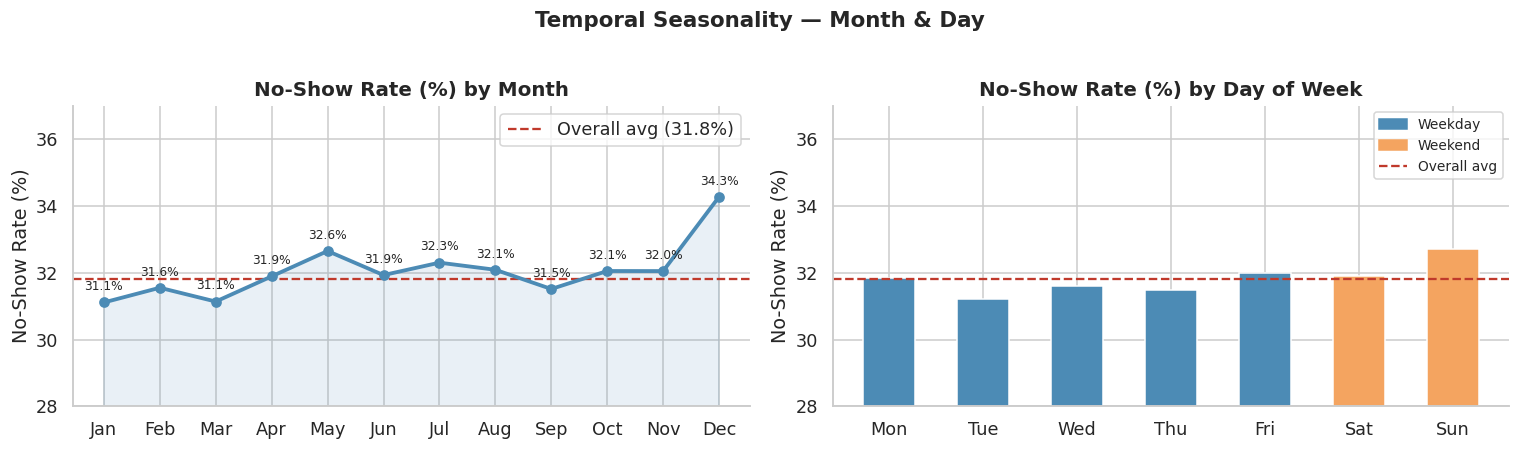

In [13]:
df['month']       = df['appointment_date'].dt.month
df['day_of_week'] = df['appointment_date'].dt.dayofweek

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
day_names   = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

monthly = (df.groupby('month')
             .agg(count=('no_show', 'count'),
                  noshow_rate=('no_show', lambda x: (x == 'yes').mean() * 100))
             .reset_index())
monthly['label'] = monthly['month'].map(month_names)

dow = (df.groupby('day_of_week')
         .agg(count=('no_show', 'count'),
              noshow_rate=('no_show', lambda x: (x == 'yes').mean() * 100))
         .reset_index())
dow['label'] = dow['day_of_week'].map(day_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Monthly line chart ────────────────────────────────────────────────────────
axes[0].plot(range(len(monthly)), monthly['noshow_rate'],
             marker='o', color=COLOR_PRI, linewidth=2.5, zorder=3)
axes[0].fill_between(range(len(monthly)), monthly['noshow_rate'], alpha=0.12, color=COLOR_PRI)
axes[0].set_xticks(range(len(monthly)))
axes[0].set_xticklabels(monthly['label'])
axes[0].axhline(31.8, color=COLOR_AVG, linestyle='--', linewidth=1.5, label='Overall avg (31.8%)')
axes[0].set_title('No-Show Rate (%) by Month')
axes[0].set_ylabel('No-Show Rate (%)')
axes[0].set_ylim(28, 37)
axes[0].legend()
for i, row in monthly.iterrows():
    axes[0].annotate(f"{row['noshow_rate']:.1f}%",
                     (i, row['noshow_rate']), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)

# ── Day-of-week bar chart ─────────────────────────────────────────────────────
bar_colors = [COLOR_SEC if d >= 5 else COLOR_PRI for d in dow['day_of_week']]
axes[1].bar(dow['label'], dow['noshow_rate'], color=bar_colors, edgecolor='white', width=0.55)
axes[1].axhline(31.8, color=COLOR_AVG, linestyle='--', linewidth=1.5)
axes[1].set_title('No-Show Rate (%) by Day of Week')
axes[1].set_ylabel('No-Show Rate (%)')
axes[1].set_ylim(28, 37)
weekday_patch = mpatches.Patch(color=COLOR_PRI, label='Weekday')
weekend_patch = mpatches.Patch(color=COLOR_SEC, label='Weekend')
avg_line      = plt.Line2D([0], [0], color=COLOR_AVG, linestyle='--', label='Overall avg')
axes[1].legend(handles=[weekday_patch, weekend_patch, avg_line], fontsize=9)

plt.suptitle('Temporal Seasonality — Month & Day', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations — Monthly & Weekly Patterns**

- **Monthly variation is narrow** — rates range from ~31.1% (January) to ~34.3% (December), a spread of only ~3 pp.  
  December's spike likely reflects end-of-year holidays disrupting family routines.
- **Day-of-week variation is equally modest** (~31.2% Tuesday to ~32.7% Sunday) — attendance behaviour is fairly consistent through the week.
- **Sunday** has the highest rate (32.7%) but very few scheduled appointments, so the operational impact is limited.

**Implication:** Month and day-of-week are statistically present but operationally small effects. They are more valuable as features for the **demand forecasting model** (which must predict daily volume) than for the no-show classifier. The December spike warrants proactive reminder campaigns in November–December.

### 3.7 Weather Conditions vs No-Show

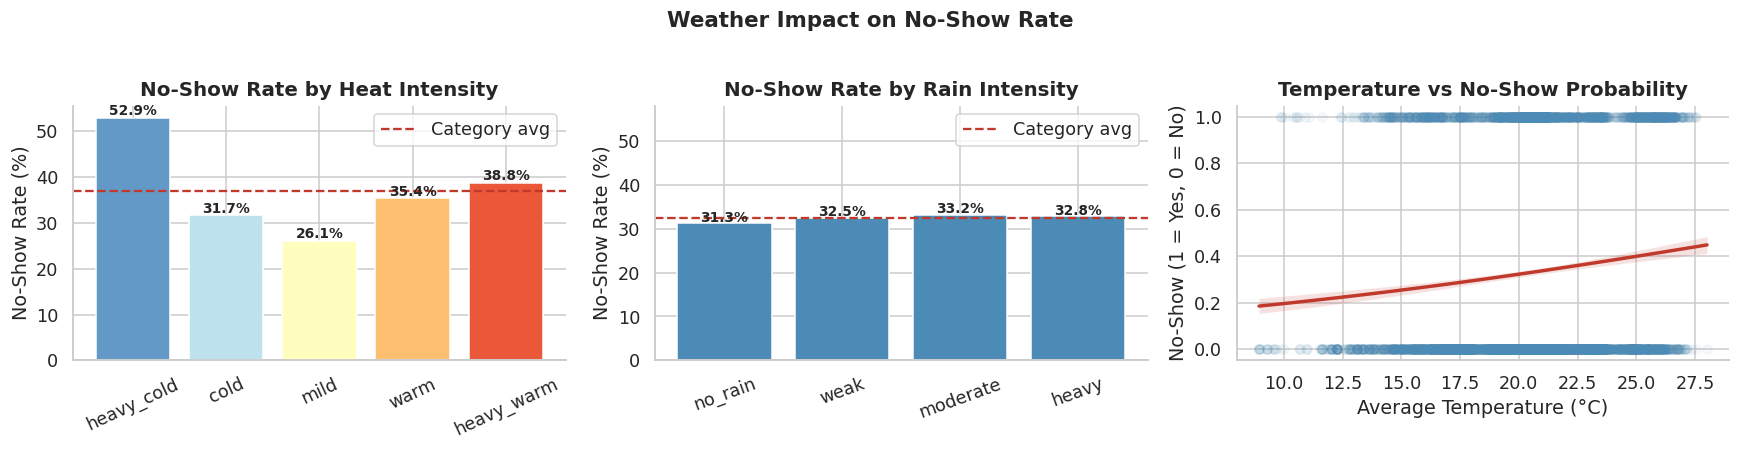

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Heat intensity ────────────────────────────────────────────────────────────
heat_order = ['heavy_cold', 'cold', 'mild', 'warm', 'heavy_warm']
heat_rates = (df.groupby('heat_intensity')['no_show']
               .apply(lambda x: (x == 'yes').mean() * 100)
               .reindex([h for h in heat_order if h in df['heat_intensity'].unique()]))
colors_heat = sns.color_palette('RdYlBu_r', len(heat_rates))
bars = axes[0].bar(heat_rates.index, heat_rates.values, color=colors_heat, edgecolor='white')
axes[0].axhline(heat_rates.mean(), color=COLOR_AVG, linestyle='--', linewidth=1.5, label='Category avg')
for bar, v in zip(bars, heat_rates.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.5,
                 f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('No-Show Rate by Heat Intensity')
axes[0].set_ylabel('No-Show Rate (%)')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend()

# ── Rain intensity ────────────────────────────────────────────────────────────
rain_order = ['no_rain', 'weak', 'moderate', 'heavy']
rain_rates = (df.groupby('rain_intensity')['no_show']
               .apply(lambda x: (x == 'yes').mean() * 100)
               .reindex([r for r in rain_order if r in df['rain_intensity'].unique()]))
bars2 = axes[1].bar(rain_rates.index, rain_rates.values, color=COLOR_PRI, edgecolor='white')
axes[1].axhline(rain_rates.mean(), color=COLOR_AVG, linestyle='--', linewidth=1.5, label='Category avg')
for bar, v in zip(bars2, rain_rates.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.3,
                 f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('No-Show Rate by Rain Intensity')
axes[1].set_ylabel('No-Show Rate (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(0, 58)
axes[1].legend()

# ── Temperature scatter with logistic regression curve ────────────────────────
sample = df.dropna(subset=['average_temp_day']).sample(5000, random_state=42).copy()
sample['no_show_flag'] = (sample['no_show'] == 'yes').astype(int)
sns.regplot(data=sample, x='average_temp_day', y='no_show_flag',
            logistic=True,
            scatter_kws={'alpha': 0.05, 'color': COLOR_PRI},
            line_kws={'color': COLOR_AVG},
            ax=axes[2])
axes[2].set_xlabel('Average Temperature (°C)')
axes[2].set_title('Temperature vs No-Show Probability')
axes[2].set_ylabel('No-Show (1 = Yes, 0 = No)')

plt.suptitle('Weather Impact on No-Show Rate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations — Weather**

- **Temperature is the strongest weather signal:**
  - `heavy_cold` days (≤ ~15 °C) → **52.9% no-show** — nearly 21 pp above the overall average.
  - `mild` days → **26.1%** — the safest condition for attendance.
  - The relationship is **non-linear**: both extremes (heavy cold and heavy warm) increase no-shows.
- **Rain intensity has minimal discriminating power** — rates range from 31.3% (no rain) to 33.2% (moderate), a spread of only ~2 pp. Heavy rain does not meaningfully change no-show behaviour.
- The `sns.regplot` logistic curve confirms that the probability of no-show **rises at temperature extremes**.

> **Data Quirk:** `rainy_day_before` and `storm_day_before` appear **inversely encoded** — the group coded 0 has a ~56% no-show rate vs ~30% for the group coded 1. Cross-validation with `average_rain_day` confirms this encoding. We keep the columns as-is; tree-based models learn the correct split direction automatically.

**Implication:** `heat_intensity` should be one-hot or label encoded (non-linear effect). Raw `average_temp_day` will also be retained for continuous temperature effects.

### 3.8 Health Conditions & Socioeconomic Factors

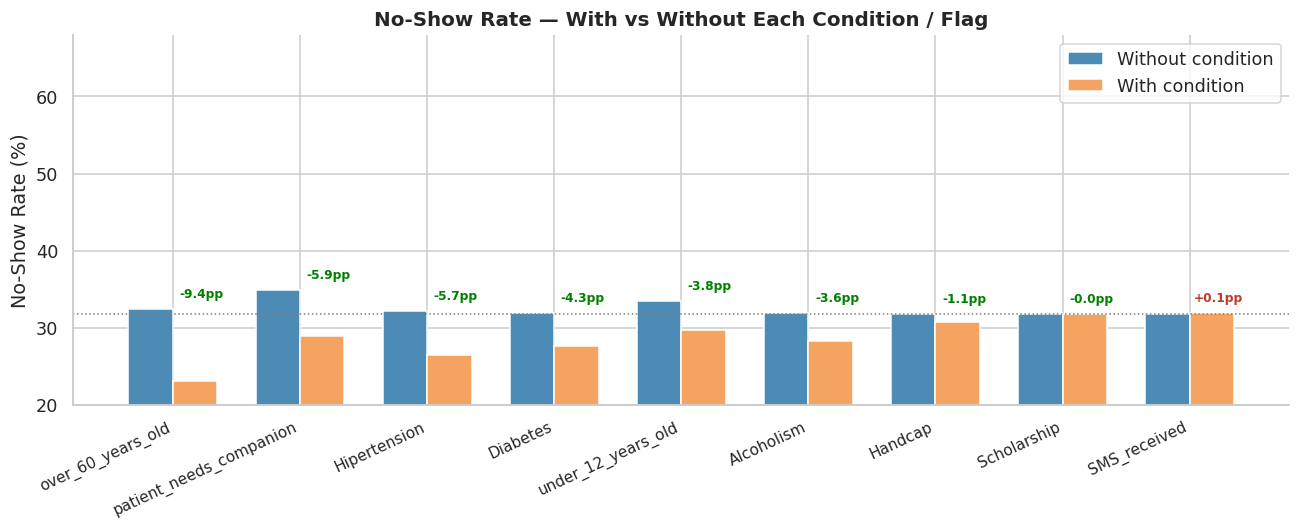

              Condition  Without (%)  With (%)  Diff (pp)  Count With
      over_60_years_old         32.5      23.0       -9.4        7817
patient_needs_companion         34.8      29.0       -5.9       56969
           Hipertension         32.1      26.4       -5.7        6366
               Diabetes         31.9      27.6       -4.3        2625
     under_12_years_old         33.5      29.7       -3.8       48925
             Alcoholism         31.8      28.2       -3.6        2032
                Handcap         31.8      30.7       -1.1         999
            Scholarship         31.8      31.8       -0.0        6040
           SMS_received         31.8      31.9        0.1       34172


In [15]:
condition_cols = [
    'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap',
    'Scholarship', 'SMS_received',
    'patient_needs_companion', 'under_12_years_old', 'over_60_years_old'
]

rows = []
for col in condition_cols:
    r0 = (df[df[col] == 0]['no_show'] == 'yes').mean() * 100
    r1 = (df[df[col] == 1]['no_show'] == 'yes').mean() * 100
    rows.append({'Condition': col, 'Without (%)': r0, 'With (%)': r1,
                 'Diff (pp)': r1 - r0, 'Count With': (df[col] == 1).sum()})

cond_df = pd.DataFrame(rows).sort_values('Diff (pp)')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(cond_df))
w = 0.35
bars_wo = ax.bar(x - w/2, cond_df['Without (%)'], width=w, color=COLOR_PRI, label='Without condition', edgecolor='white')
bars_wi = ax.bar(x + w/2, cond_df['With (%)'],    width=w, color=COLOR_SEC, label='With condition',    edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(cond_df['Condition'], rotation=25, ha='right', fontsize=10)
ax.set_ylabel('No-Show Rate (%)')
ax.set_title('No-Show Rate — With vs Without Each Condition / Flag', fontsize=13, fontweight='bold')
ax.set_ylim(20, 68)
ax.axhline(31.8, color='grey', linestyle=':', linewidth=1)
ax.legend()

for b_wo, b_wi, row in zip(bars_wo, bars_wi, cond_df.itertuples()):
    diff  = row._4   # Diff (pp)
    color = 'green' if diff < 0 else COLOR_AVG
    ax.text(b_wi.get_x() + b_wi.get_width() / 2 + 0.05,
            max(row._3, row._2) + 1.5,
            f'{diff:+.1f}pp', ha='center', fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.show()

print(cond_df[['Condition', 'Without (%)', 'With (%)', 'Diff (pp)', 'Count With']].round(1).to_string(index=False))

**Observations — Health Conditions & Social Flags**

| Condition | With (%) | Without (%) | Δ (pp) | Interpretation |
|-----------|----------|-------------|--------|----------------|
| `over_60_years_old` | 23.0 | 32.5 | **−9.5** | Elderly patients are most reliable |
| `patient_needs_companion` | 29.0 | 34.8 | **−5.8** | Companion creates accountability |
| `Hypertension` | 26.4 | 32.1 | **−5.7** | Chronic disease patients are appointment-dependent |
| `Diabetes` | 27.6 | 31.9 | **−4.3** | Same pattern as hypertension |
| `under_12_years_old` | 29.7 | 33.5 | **−3.8** | Caregivers prioritise children's therapy |
| `SMS_received` | 31.9 | 31.8 | **~0** | Current SMS system has **no measurable effect** |
| `Scholarship` | 31.8 | 31.8 | **~0** | Socioeconomic subsidy alone doesn't predict attendance |

**Key findings:**
1. **Chronic disease patients attend more reliably** — counterintuitive but consistent with clinical research (higher perceived urgency).
2. **SMS reminders are ineffective** in this dataset — they may be sent too early/late, contain generic content, or reach patients who would have attended anyway. This warrants a re-evaluation of the clinic's reminder strategy.
3. **All binary flags carry signal** and should be included in the model despite modest individual correlations.

### 3.9 Disability Type vs No-Show

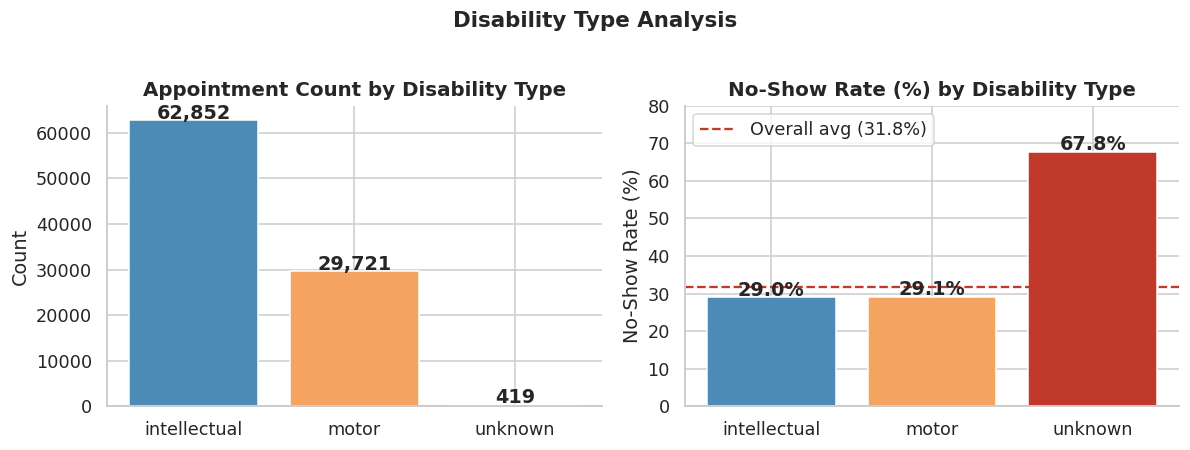

In [16]:
dis_stats = df[df['disability'].notna()].copy()
dis_stats['disability_clean'] = dis_stats['disability'].str.strip().replace('', 'unknown')

dis_rates  = (dis_stats.groupby('disability_clean')['no_show']
               .apply(lambda x: (x == 'yes').mean() * 100)
               .reset_index(name='NoShow%'))
dis_counts = dis_stats['disability_clean'].value_counts().reset_index()
dis_counts.columns = ['disability_clean', 'Count']
dis_merged = dis_rates.merge(dis_counts, on='disability_clean')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

palette_dis = sns.color_palette(PALETTE[:2] + [COLOR_AVG] * max(0, len(dis_merged)-2))
bars = axes[0].bar(dis_merged['disability_clean'], dis_merged['Count'],
                   color=palette_dis, edgecolor='white')
for bar, v in zip(bars, dis_merged['Count']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 300, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Appointment Count by Disability Type')
axes[0].set_ylabel('Count')

bars2 = axes[1].bar(dis_merged['disability_clean'], dis_merged['NoShow%'],
                    color=palette_dis, edgecolor='white')
axes[1].axhline(31.8, color=COLOR_AVG, linestyle='--', linewidth=1.5, label='Overall avg (31.8%)')
for bar, v in zip(bars2, dis_merged['NoShow%']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.5,
                 f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('No-Show Rate (%) by Disability Type')
axes[1].set_ylabel('No-Show Rate (%)')
axes[1].set_ylim(0, 80)
axes[1].legend()

plt.suptitle('Disability Type Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations — Disability Type**

- **Intellectual disabilities** dominate (≈62,852 records, ~68% of classified cases), followed by motor disabilities (≈29,721).
- Both classified disability types show **similar, below-average no-show rates (~29%)** — patients with diagnosed conditions attend more reliably (consistent with Section 3.8).
- The **blank/unclassified disability category** (n ≈ 419) has an alarming **67.8% no-show rate** — the highest of any group. These may be unregistered patients, administrative errors, or walk-in records.

**Implication:** Missing disability entries must be preserved as `'unknown'` — they carry a strong, distinct no-show signal (67.8%) that would be lost if imputed to intellectual/motor. This validates the decision to use `'unknown'` as a real category rather than imputing.

### 3.10 Geographic Location (City) vs No-Show

In [17]:
print(f"Unique places: {df['place'].nunique()}")
print("\nTop 15 places by volume:")
print(df['place'].value_counts().head(15).to_string())

Unique places: 26289

Top 15 places by volume:
place
ITAJAÍ            20515
B. CAMBORIU        6018
CAMBORIU           5523
NAVEGANTES         3901
ITAPEMA            2665
BOMBINHAS          1707
PENHA              1039
PORTO BELO          950
BALN. PIÇARRAS      945
ILHOTA              583
LUIZ ALVES          523
New Michael          56
North Michael        51
Lake Michael         43
South James          43


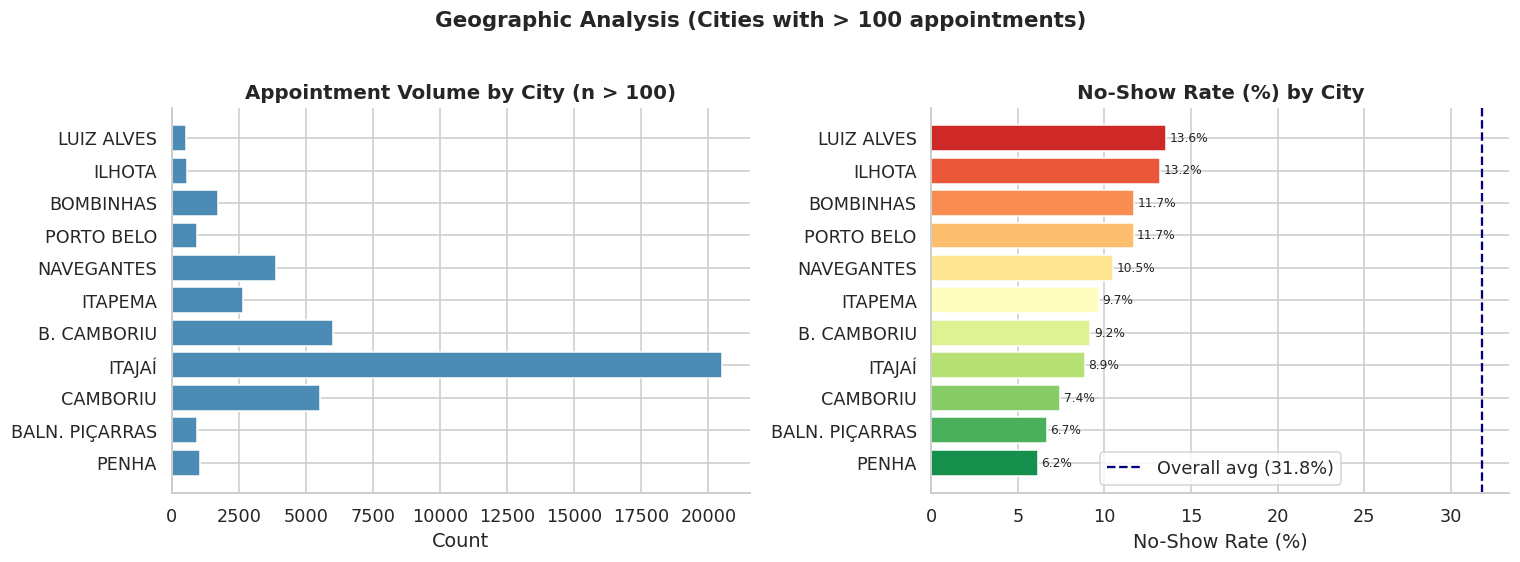

In [18]:
place_agg = (df[df['place'].notna()]
               .groupby('place')
               .agg(count=('no_show', 'count'),
                    noshow_rate=('no_show', lambda x: (x == 'yes').mean() * 100))
               .reset_index()
               .query('count > 100')
               .sort_values('noshow_rate', ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(place_agg['place'], place_agg['count'], color=COLOR_PRI, edgecolor='white')
axes[0].set_title('Appointment Volume by City (n > 100)')
axes[0].set_xlabel('Count')

colors_p = sns.color_palette('RdYlGn_r', len(place_agg))
axes[1].barh(place_agg['place'], place_agg['noshow_rate'], color=colors_p, edgecolor='white')
axes[1].axvline(31.8, color='navy', linestyle='--', linewidth=1.5, label='Overall avg (31.8%)')
axes[1].set_title('No-Show Rate (%) by City')
axes[1].set_xlabel('No-Show Rate (%)')
axes[1].legend()
for i, (_, row) in enumerate(place_agg.iterrows()):
    axes[1].text(row['noshow_rate'] + 0.2, i, f"{row['noshow_rate']:.1f}%", va='center', fontsize=8)

plt.suptitle('Geographic Analysis (Cities with > 100 appointments)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations — Geography**

- **Itajaí** dominates volume — it is the CER facility's home city, so local patients comprise the majority.
- **Remote cities** (Luiz Alves, Ilhota, Bombinhas) have the highest no-show rates (~11–14%), while Itajaí patients have the lowest rate (~8.9%).
- This is a classic **distance-decay effect**: patients who travel farther face more logistical barriers (transport, cost, time off work) and are more likely to miss.

**Implication:** `place` should be encoded and included in the model. Operationally, the clinic could prioritise outreach to patients from distant cities and explore telehealth or satellite scheduling as alternatives.

### 3.11 Correlation Heatmap (Numeric Features)

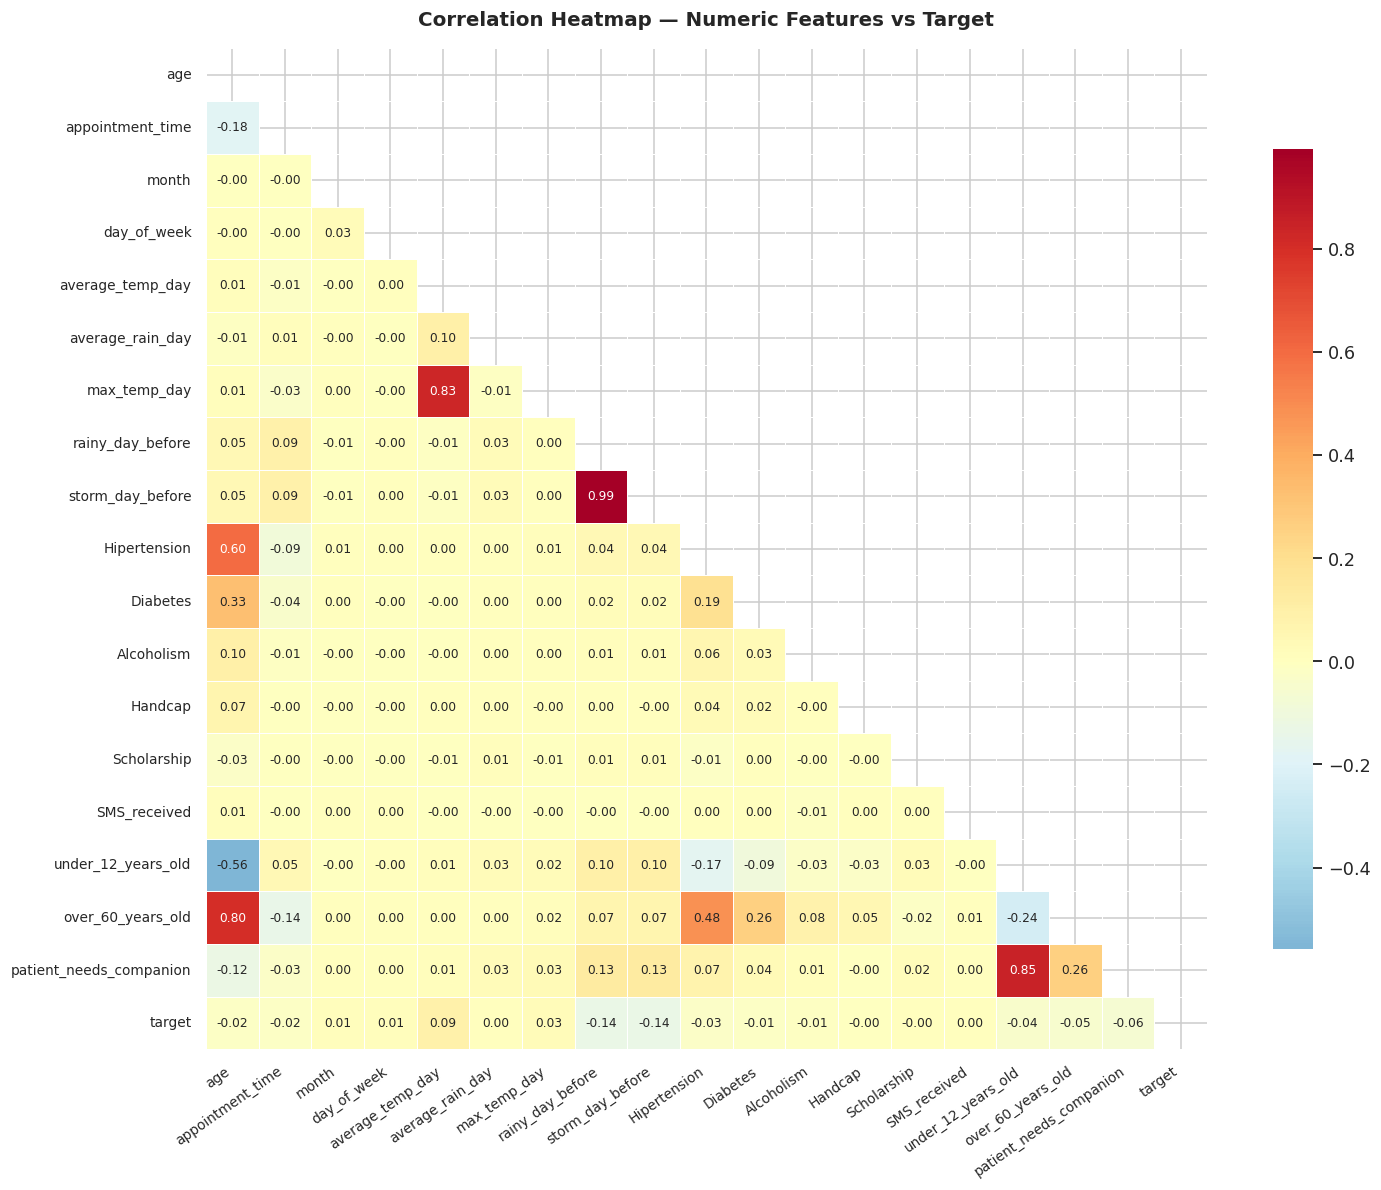


Correlations with 'target' (no-show), sorted:
storm_day_before          -0.1355
rainy_day_before          -0.1350
patient_needs_companion   -0.0629
over_60_years_old         -0.0521
under_12_years_old        -0.0404
Hipertension              -0.0286
age                       -0.0215
appointment_time          -0.0192
Diabetes                  -0.0141
Alcoholism                -0.0104
Handcap                   -0.0022
Scholarship               -0.0001
SMS_received               0.0010
average_rain_day           0.0042
day_of_week                0.0058
month                      0.0078
max_temp_day               0.0271
average_temp_day           0.0908


In [19]:
df['target'] = (df['no_show'] == 'yes').astype(int)

num_cols_corr = [
    'age', 'appointment_time', 'month', 'day_of_week',
    'average_temp_day', 'average_rain_day', 'max_temp_day',
    'rainy_day_before', 'storm_day_before',
    'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap',
    'Scholarship', 'SMS_received',
    'under_12_years_old', 'over_60_years_old', 'patient_needs_companion',
    'target'
]

corr_mat = df[num_cols_corr].corr()
mask     = np.triu(np.ones_like(corr_mat, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, ax=ax,
            linewidths=0.4, square=True, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Numeric Features vs Target', pad=15,
             fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print("\nCorrelations with 'target' (no-show), sorted:")
print(corr_mat['target'].drop('target').sort_values().round(4).to_string())

**Observations — Correlation Analysis**

**Strongest protective features (negative correlation with no-show):**
- `storm_day_before` / `rainy_day_before` (−0.14 each) — note the inverted encoding discussed in Section 3.7
- `patient_needs_companion` (−0.06), `over_60_years_old` (−0.05), `Hypertension` (−0.03)

**Strongest risk-increasing features (positive correlation):**
- `average_temp_day` (+0.09) — temperature extremes increase no-shows

**Feature inter-correlations of note:**
- `rainy_day_before` & `storm_day_before` are nearly perfectly correlated (+0.99) — they carry near-identical information. Both are retained; tree models will automatically down-weight one.
- `average_temp_day` & `max_temp_day` are highly correlated (+0.96) — multicollinearity concern for linear models, but not for tree-based models.

**Takeaway:** No single numeric feature dominates (max |r| ≈ 0.14). This is a **weak-signal problem** where combining many modest predictors is essential — exactly the scenario where gradient-boosted ensemble methods (XGBoost, LightGBM) excel over simple logistic regression.

### 3.12 Time Series — Daily Appointment Volume

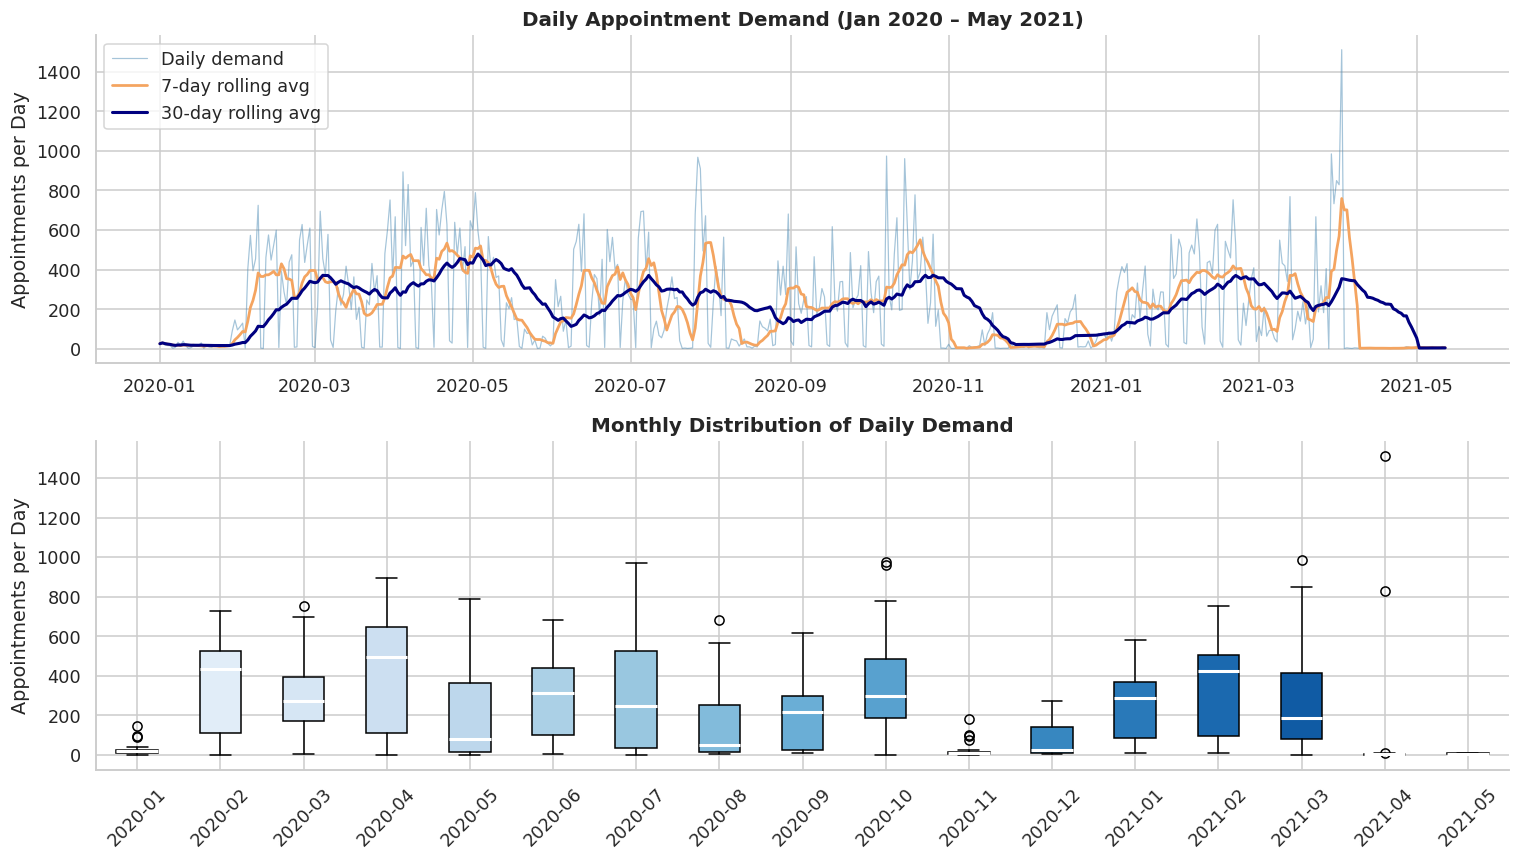

Date range : 2020-01-01 → 2021-05-12
Total days : 498
Mean/day   : 220.1  |  Std: 245.8
Min / Max  : 1 / 1512


In [20]:
daily_ts = (df.groupby('appointment_date').size()
              .reset_index(name='demand')
              .sort_values('appointment_date')
              .reset_index(drop=True))

daily_ts['rolling_7']  = daily_ts['demand'].rolling(7,  min_periods=1).mean()
daily_ts['rolling_30'] = daily_ts['demand'].rolling(30, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ── Line chart with rolling averages ─────────────────────────────────────────
axes[0].plot(daily_ts['appointment_date'], daily_ts['demand'],
             color=COLOR_PRI, linewidth=0.8, alpha=0.5, label='Daily demand')
axes[0].plot(daily_ts['appointment_date'], daily_ts['rolling_7'],
             color=COLOR_SEC, linewidth=1.8, label='7-day rolling avg')
axes[0].plot(daily_ts['appointment_date'], daily_ts['rolling_30'],
             color='navy', linewidth=2, label='30-day rolling avg')
axes[0].set_title('Daily Appointment Demand (Jan 2020 – May 2021)')
axes[0].set_ylabel('Appointments per Day')
axes[0].legend()

# ── Monthly boxplot distribution ──────────────────────────────────────────────
daily_ts['month_label'] = pd.to_datetime(daily_ts['appointment_date']).dt.strftime('%Y-%m')
months   = sorted(daily_ts['month_label'].unique())
bp_data  = [daily_ts[daily_ts['month_label'] == m]['demand'].values for m in months]
bp = axes[1].boxplot(bp_data, labels=months, patch_artist=True,
                     medianprops={'color': 'white', 'linewidth': 2})
for patch, c in zip(bp['boxes'], sns.color_palette('Blues', len(months))):
    patch.set_facecolor(c)
axes[1].set_title('Monthly Distribution of Daily Demand')
axes[1].set_ylabel('Appointments per Day')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Date range : {daily_ts['appointment_date'].min().date()} → {daily_ts['appointment_date'].max().date()}")
print(f"Total days : {len(daily_ts)}")
print(f"Mean/day   : {daily_ts['demand'].mean():.1f}  |  Std: {daily_ts['demand'].std():.1f}")
print(f"Min / Max  : {daily_ts['demand'].min()} / {daily_ts['demand'].max()}")

**Observations — Time Series Demand**

- The series spans **498 days** but is **extremely volatile**: mean ≈ 220 appointments/day, std ≈ 246 — the standard deviation exceeds the mean, indicating high day-to-day variability.
- A clear **pandemic disruption** is visible: strong demand in early 2020 (pre-March), sharp drop, then gradual recovery through 2021. This structural break makes the series non-stationary.
- Monthly boxplots confirm high within-month variance — some days see 1–5 appointments (weekends/holidays) while peak days exceed 1,500.

**Implication for Forecasting:**  
The pandemic break, combined with std > mean, makes this a **hard forecasting problem**. A feature-based ML regressor with lag features (yesterday's demand, same weekday last week) will outperform classical ARIMA because it handles non-stationarity and structural breaks more robustly. Expect moderate R² values (~0.15–0.20) given the noise.

---
## Section 4 — Data Preprocessing & Feature Engineering

### Summary of preprocessing decisions (from EDA)

| Column | Issue | Decision | Rationale |
|--------|-------|----------|-----------| 
| `Hipertension` | Misspelled | Rename to `Hypertension` | Clarity |
| `age` | 21% missing, max=110 | Fill median (12), clip at 100 | Preserves right-skew; removes extreme outlier |
| `specialty` | 18% missing | Fill `'unknown'` | Missing = 52.8% no-show — a strong unique signal |
| `disability` | 15% missing | Fill `'unknown'` | Blank = 67.8% no-show — must not be imputed |
| `place` | 10.5% missing | Fill `'unknown'` | Preserve as distinct behavioural category |
| Weather cols | ≤ 2.1% missing | Fill column **median** | Minimal gap; distribution unchanged |
| Categorical cols | String type | **LabelEncoder** | Correct for tree-based models; avoids OHE column explosion |
| `target` | String "yes/no" | Binary encode 1/0 | Required for all sklearn classifiers |

In [21]:
# ── Copy working dataframe and fix column name ────────────────────────────────
df_ml = df.copy()
df_ml = df_ml.rename(columns={'Hipertension': 'Hypertension'})
print("Renamed 'Hipertension' → 'Hypertension'")

Renamed 'Hipertension' → 'Hypertension'


In [22]:
# ── 4.1  Date Features ────────────────────────────────────────────────────────
df_ml['appointment_date'] = pd.to_datetime(df_ml['appointment_date_continuous'])
df_ml['month']            = df_ml['appointment_date'].dt.month
df_ml['day_of_week']      = df_ml['appointment_date'].dt.dayofweek
df_ml['week_of_year']     = df_ml['appointment_date'].dt.isocalendar().week.astype(int)
df_ml['quarter']          = df_ml['appointment_date'].dt.quarter
df_ml['is_weekend']       = (df_ml['day_of_week'] >= 5).astype(int)

print("Date features created:", ['month', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend'])

Date features created: ['month', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend']


In [23]:
# ── 4.2  Impute Missing Values ─────────────────────────────────────────────────
age_median = df_ml['age'].median()
print(f"Age median (imputation value): {age_median} years")

df_ml['age']        = df_ml['age'].fillna(age_median).clip(0, 100)
df_ml['specialty']  = df_ml['specialty'].fillna('unknown')
df_ml['disability'] = df_ml['disability'].fillna('unknown').str.strip().replace('', 'unknown')
df_ml['place']      = df_ml['place'].fillna('unknown')

weather_cols = ['average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day']
for col in weather_cols:
    med = df_ml[col].median()
    n_missing = df[col].isna().sum()
    df_ml[col] = df_ml[col].fillna(med)
    print(f"  {col:25s} → filled {n_missing} NaNs with median = {med:.2f}")

total_na = df_ml.isnull().sum().sum()
print(f"\nTotal remaining NaNs across all columns: {total_na}")

Age median (imputation value): 12.0 years
  average_temp_day          → filled 2211 NaNs with median = 20.60
  average_rain_day          → filled 2245 NaNs with median = 0.01
  max_temp_day              → filled 2227 NaNs with median = 23.90
  max_rain_day              → filled 2263 NaNs with median = 0.20

Total remaining NaNs across all columns: 0


**Verification — Missing Values**

After this step, **zero missing values remain** in any modelling-relevant column.  
The `'unknown'` string categories now represent a **real behavioural signal** (not data gaps) and will be treated as valid classes by the encoder.  
Importantly, the imputation for `specialty` and `disability` preserves the distinct no-show signal these groups carry (52.8% and 67.8% respectively).

In [24]:
# ── 4.3  Target Encoding ──────────────────────────────────────────────────────
df_ml['target'] = (df_ml['no_show'] == 'yes').astype(int)
print("Target distribution:")
print(df_ml['target'].value_counts()
                     .to_frame('count')
                     .assign(pct=lambda d: (d['count'] / d['count'].sum() * 100).round(2))
                     .rename(index={0: 'Attended (0)', 1: 'No-Show (1)'}))

Target distribution:
              count    pct
target                    
Attended (0)  74761  68.22
No-Show (1)   34832  31.78


In [25]:
# ── 4.4  Label Encode Categorical Features ────────────────────────────────────
cat_cols = [
    'gender', 'specialty', 'disability', 'place',
    'appointment_shift', 'heat_intensity', 'rain_intensity'
]

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col].astype(str))
    le_dict[col] = le
    print(f"  {col:25s} → {len(le.classes_)} classes → integers 0–{len(le.classes_)-1}")

# Persist encoders and metadata for deployment
joblib.dump(le_dict,    f'{MODELS_DIR}/label_encoders.pkl')
joblib.dump(age_median, f'{MODELS_DIR}/age_median.pkl')

cat_options = {col: sorted(df[col].dropna().unique().tolist()) for col in cat_cols}
joblib.dump(cat_options, f'{MODELS_DIR}/cat_options.pkl')
print("\nLabel encoders saved.")

  gender                    → 3 classes → integers 0–2
  specialty                 → 9 classes → integers 0–8
  disability                → 3 classes → integers 0–2
  place                     → 26290 classes → integers 0–26289
  appointment_shift         → 2 classes → integers 0–1
  heat_intensity            → 5 classes → integers 0–4
  rain_intensity            → 4 classes → integers 0–3

Label encoders saved.


**Why LabelEncoder over One-Hot Encoding?**

We use LabelEncoder (integer mapping) instead of One-Hot Encoding (OHE) because:
1. All classifiers are **tree-based** (Decision Tree, Random Forest, XGBoost, LightGBM) — trees split on thresholds, so integer labels work correctly without implying ordinality.
2. `specialty` has 8 classes and `place` has ~15 — OHE would add 20+ sparse binary columns, inflating memory and training time with minimal benefit for tree models.
3. For Logistic Regression (baseline only), LabelEncoding does imply ordering — this is a known limitation but acceptable since LR serves only as a performance baseline.

In [26]:
# ── 4.5  Feature Set Definition ───────────────────────────────────────────────
FEATURES = [
    # Encoded categoricals
    'gender_enc', 'specialty_enc', 'disability_enc', 'place_enc',
    'appointment_shift_enc', 'heat_intensity_enc', 'rain_intensity_enc',
    # Patient demographics
    'age', 'under_12_years_old', 'over_60_years_old', 'patient_needs_companion',
    # Appointment logistics
    'appointment_time', 'month', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend',
    # Weather (numeric)
    'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day',
    'rainy_day_before', 'storm_day_before',
    # Health & social flags
    'Hypertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received'
]

X = df_ml[FEATURES]
y = df_ml['target']

joblib.dump(FEATURES, f'{MODELS_DIR}/features.pkl')

print(f"Feature matrix shape : {X.shape}")
print(f"\nFinal feature list ({len(FEATURES)} features):")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2d}. {f}")

Feature matrix shape : (109593, 29)

Final feature list (29 features):
   1. gender_enc
   2. specialty_enc
   3. disability_enc
   4. place_enc
   5. appointment_shift_enc
   6. heat_intensity_enc
   7. rain_intensity_enc
   8. age
   9. under_12_years_old
  10. over_60_years_old
  11. patient_needs_companion
  12. appointment_time
  13. month
  14. day_of_week
  15. week_of_year
  16. quarter
  17. is_weekend
  18. average_temp_day
  19. average_rain_day
  20. max_temp_day
  21. max_rain_day
  22. rainy_day_before
  23. storm_day_before
  24. Hypertension
  25. Diabetes
  26. Alcoholism
  27. Handcap
  28. Scholarship
  29. SMS_received


**Feature Engineering Rationale**

| Feature Group | Features | Rationale |
|---------------|----------|-----------|
| Encoded categoricals | `gender_enc`, `specialty_enc`, etc. | Converts string categories to integers for tree-based models |
| Temporal | `month`, `day_of_week`, `week_of_year`, `quarter`, `is_weekend` | Captures seasonal cycles in attendance behaviour |
| Demographics | `age`, `under_12_years_old`, `over_60_years_old`, `patient_needs_companion` | Age non-linearity captured via both continuous and binary forms |
| Logistics | `appointment_time`, `appointment_shift_enc` | Time-of-day effects on attendance |
| Weather | `average_temp_day`, `heat_intensity_enc`, `rain_intensity_enc`, etc. | Temperature is the strongest weather predictor |
| Health/Social | `Hypertension`, `Diabetes`, `SMS_received`, etc. | Chronic disease = lower no-show; SMS = no current effect |

All 29 features are retained — tree-based models are robust to multicollinearity and will automatically down-weight redundant features.

---
## Section 5 — No-Show Classification

Five classifiers are evaluated: Logistic Regression (baseline), Decision Tree, Random Forest, XGBoost, and LightGBM.  
All use a `Pipeline(SMOTE → model)` approach with hyperparameter tuning via cross-validated search.  
The best model is selected by ROC-AUC on the hold-out test set.

In [27]:
# ── 5.1  Stratified Train / Test Split ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]:,} rows  |  {y_train.mean()*100:.1f}% no-show")
print(f"Test set     : {X_test.shape[0]:,} rows  |  {y_test.mean()*100:.1f}% no-show")
print("\nStratified split — original class ratio preserved in both sets.")

Training set : 76,715 rows  |  31.8% no-show
Test set     : 32,878 rows  |  31.8% no-show

Stratified split — original class ratio preserved in both sets.


In [28]:
# ── 5.2  Logistic Regression (with StandardScaler + SMOTE pipeline) ─────────
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('model',  LogisticRegression(random_state=42))
])

param_grid_lr = {
    'model__C':            [0.01, 0.1, 1, 5, 10, 20],
    'model__solver':       ['lbfgs', 'liblinear'],
    'model__class_weight': [None, 'balanced'],
    'model__max_iter':     [500, 1000]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring={'roc_auc': 'roc_auc', 'f1': 'f1'},
    refit='roc_auc',
    cv=cv, n_jobs=-1, verbose=0
)
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
print("Best params  :", grid_lr.best_params_)
print(f"Best ROC-AUC : {grid_lr.best_score_:.4f}")
print(f"Best F1      : {grid_lr.cv_results_['mean_test_f1'][grid_lr.best_index_]:.4f}")

Best params  : {'model__C': 0.01, 'model__class_weight': None, 'model__max_iter': 500, 'model__solver': 'lbfgs'}
Best ROC-AUC : 0.6603
Best F1      : 0.5105


In [29]:
# ── Logistic Regression — Optimal threshold search ────────────────────────────
y_prob_lr   = best_lr.predict_proba(X_test)[:, 1]
base_roc_lr = roc_auc_score(y_test, y_prob_lr)

best_thresh = {'threshold': 0.5, 'f1': 0}
for t in np.arange(0.1, 0.9, 0.01):
    y_pred_t = (y_prob_lr >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    if f1 > best_thresh['f1']:
        best_thresh = {
            'threshold': round(t, 2),
            'accuracy':  accuracy_score(y_test, y_pred_t),
            'precision': precision_score(y_test, y_pred_t, zero_division=0),
            'recall':    recall_score(y_test, y_pred_t, zero_division=0),
            'f1':        f1,
            'roc_auc':   base_roc_lr
        }

print("Logistic Regression — Optimal Threshold Results")
print("-" * 45)
for k, v in best_thresh.items():
    print(f"  {k:12s}: {v:.4f}" if isinstance(v, float) else f"  {k:12s}: {v}")

Logistic Regression — Optimal Threshold Results
---------------------------------------------
  threshold   : 0.4400
  accuracy    : 0.5730
  precision   : 0.4068
  recall      : 0.7497
  f1          : 0.5274
  roc_auc     : 0.6634


In [30]:
# ── 5.3  Decision Tree ────────────────────────────────────────────────────────
pipe_dt = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42))
])

param_dist_dt = {
    'model__max_depth':         [3, 5, 7, 10, 15, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf':  [1, 2, 5, 10],
    'model__criterion':         ['gini', 'entropy']
}

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_dt = RandomizedSearchCV(
    estimator=pipe_dt, param_distributions=param_dist_dt,
    n_iter=25,
    scoring={'roc_auc': 'roc_auc', 'f1': 'f1', 'accuracy': 'accuracy'},
    refit='roc_auc', cv=cv3, n_jobs=-1, verbose=0, random_state=42
)
random_dt.fit(X_train, y_train)

best_dt = random_dt.best_estimator_
print("Best params  :", random_dt.best_params_)
print(f"Best ROC-AUC : {random_dt.best_score_:.4f}")

Best params  : {'model__min_samples_split': 5, 'model__min_samples_leaf': 5, 'model__max_depth': 10, 'model__criterion': 'entropy'}
Best ROC-AUC : 0.7264


In [31]:
# ── 5.4  Random Forest ────────────────────────────────────────────────────────
pipe_rf = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_dist_rf = {
    'model__n_estimators':      [100, 200],
    'model__max_depth':         [5, 10, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__max_features':      ['sqrt'],
    'model__bootstrap':         [True]
}

random_rf = RandomizedSearchCV(
    estimator=pipe_rf, param_distributions=param_dist_rf,
    n_iter=15,
    scoring={'roc_auc': 'roc_auc', 'f1': 'f1', 'accuracy': 'accuracy'},
    refit='roc_auc', cv=cv3, n_jobs=-1, verbose=0, random_state=42
)
random_rf.fit(X_train, y_train)

best_rf = random_rf.best_estimator_
print("Best params  :", random_rf.best_params_)
print(f"Best ROC-AUC : {random_rf.best_score_:.4f}")

Best params  : {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None, 'model__bootstrap': True}
Best ROC-AUC : 0.7603


In [32]:
# ── 5.5  XGBoost ─────────────────────────────────────────────────────────────
pipe_xgb = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='logloss',
        random_state=42, n_jobs=-1, tree_method='hist', verbosity=0
    ))
])

param_dist_xgb = {
    'model__n_estimators':      [100, 200],
    'model__max_depth':         [3, 5, 7],
    'model__learning_rate':     [0.05, 0.1],
    'model__subsample':         [0.8, 1.0],
    'model__colsample_bytree':  [0.8, 1.0],
    'model__gamma':             [0, 0.1],
    'model__min_child_weight':  [1, 3]
}

random_xgb = RandomizedSearchCV(
    estimator=pipe_xgb, param_distributions=param_dist_xgb,
    n_iter=15,
    scoring={'roc_auc': 'roc_auc', 'f1': 'f1', 'accuracy': 'accuracy'},
    refit='roc_auc', cv=cv3, n_jobs=-1, verbose=0, random_state=42
)
random_xgb.fit(X_train, y_train)

best_xgb = random_xgb.best_estimator_
print("Best params  :", random_xgb.best_params_)
print(f"Best ROC-AUC : {random_xgb.best_score_:.4f}")

Best params  : {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_child_weight': 3, 'model__max_depth': 7, 'model__learning_rate': 0.1, 'model__gamma': 0, 'model__colsample_bytree': 1.0}
Best ROC-AUC : 0.7689


In [33]:
# ── 5.6  LightGBM ────────────────────────────────────────────────────────────
pipe_lgb = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1))
])

param_dist_lgb = {
    'model__n_estimators':      [100, 200],
    'model__learning_rate':     [0.05, 0.1],
    'model__num_leaves':        [31, 50, 100],
    'model__max_depth':         [-1, 5, 10],
    'model__subsample':         [0.8, 1.0],
    'model__colsample_bytree':  [0.8, 1.0],
    'model__min_child_samples': [10, 20]
}

random_lgb = RandomizedSearchCV(
    estimator=pipe_lgb, param_distributions=param_dist_lgb,
    n_iter=15,
    scoring={'roc_auc': 'roc_auc', 'f1': 'f1', 'accuracy': 'accuracy'},
    refit='roc_auc', cv=cv3, n_jobs=-1, verbose=0, random_state=42
)
random_lgb.fit(X_train, y_train)

best_lgb = random_lgb.best_estimator_
print("Best params  :", random_lgb.best_params_)
print(f"Best ROC-AUC : {random_lgb.best_score_:.4f}")

Best params  : {'model__subsample': 1.0, 'model__num_leaves': 100, 'model__n_estimators': 100, 'model__min_child_samples': 10, 'model__max_depth': -1, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}
Best ROC-AUC : 0.7726


**Classification Model Training — Notes**

Each model is trained using the same consistent pipeline pattern:  
`Pipeline → [SMOTE oversampling → classifier] → RandomizedSearchCV / GridSearchCV`

**Why SMOTE is placed inside the pipeline (not applied globally)?**  
Applying SMOTE before cross-validation would cause data leakage — synthetic samples generated from the full training set could appear in validation folds. By placing SMOTE *inside* the pipeline, oversampling is applied only to each fold's training portion during CV, and the validation fold always contains only real, original data.

**Hyperparameter search strategy:**
- **Logistic Regression** → `GridSearchCV` (small parameter space, exhaustive search feasible)
- **Decision Tree, Random Forest, XGBoost, LightGBM** → `RandomizedSearchCV` (large parameter spaces; random search finds near-optimal solutions faster)
- **Refit metric** → `roc_auc` for all models, ensuring model selection is consistent and threshold-independent

In [34]:
# ── 5.7  Evaluate all models on hold-out test set ──────────────────────────────
best_models = {
    'Logistic Regression': best_lr,
    'Decision Tree':       best_dt,
    'Random Forest':       best_rf,
    'XGBoost':             best_xgb,
    'LightGBM':            best_lgb
}

results = {}

print(f"{'Model':<22} | {'Accuracy':>8} | {'Precision':>9} | {'Recall':>6} | {'F1':>6} | {'ROC-AUC':>7}")
print('-' * 70)

for name, model in best_models.items():
    model.fit(X_train, y_train)   # Ensure final fit on full training set
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_prob':   y_prob,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_prob) if y_prob is not None else None
    }
    r = results[name]
    print(f"{name:<22} | {r['accuracy']:>8.3f} | {r['precision']:>9.3f} | "
          f"{r['recall']:>6.3f} | {r['f1']:>6.3f} | {r['roc_auc']:>7.3f}")

Model                  | Accuracy | Precision | Recall |     F1 | ROC-AUC
----------------------------------------------------------------------
Logistic Regression    |    0.641 |     0.451 |  0.590 |  0.511 |   0.663
Decision Tree          |    0.681 |     0.499 |  0.676 |  0.574 |   0.731
Random Forest          |    0.716 |     0.556 |  0.536 |  0.546 |   0.767
XGBoost                |    0.721 |     0.567 |  0.514 |  0.539 |   0.775
LightGBM               |    0.726 |     0.575 |  0.526 |  0.549 |   0.780


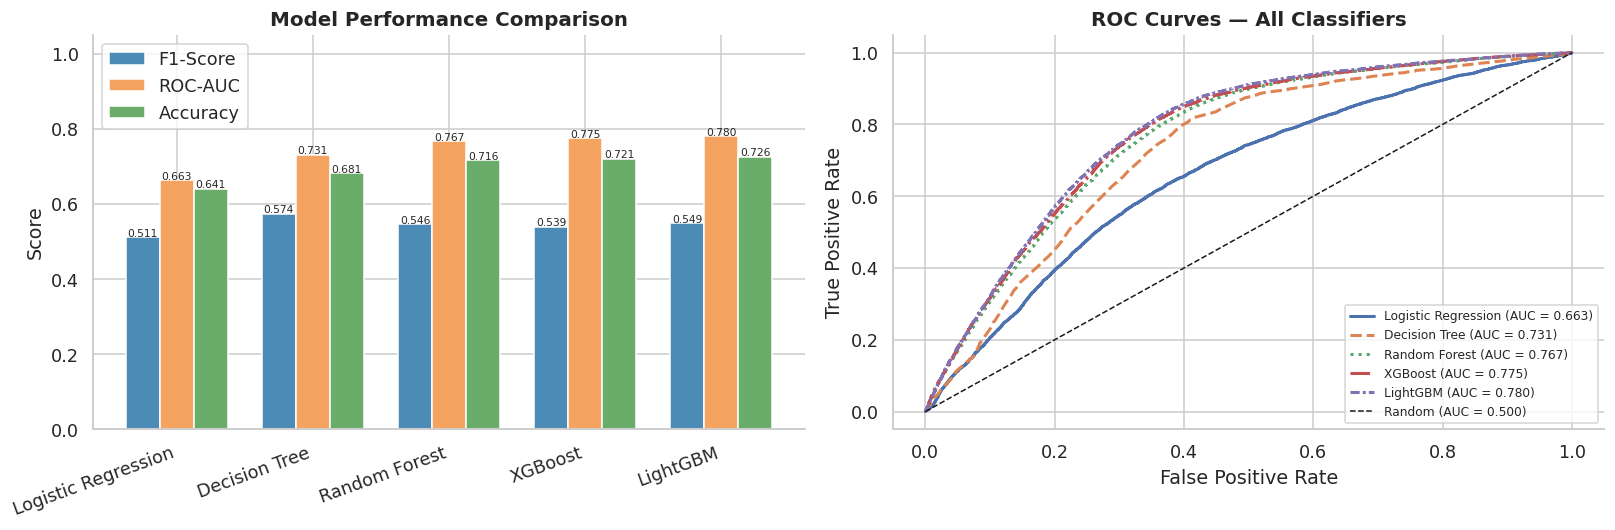

In [35]:
# ── 5.8  Performance Comparison Chart + ROC Curves ───────────────────────────
metrics_df = pd.DataFrame({
    name: {k: v for k, v in r.items() if k not in ('model', 'y_pred', 'y_prob')}
    for name, r in results.items()
}).T.round(4)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grouped bar chart
metric_cols   = ['f1', 'roc_auc', 'accuracy']
metric_labels = ['F1-Score', 'ROC-AUC', 'Accuracy']
x = np.arange(len(results))
w = 0.25
bar_palette = [COLOR_PRI, COLOR_SEC, '#6AAC6A']
for i, (col, label) in enumerate(zip(metric_cols, metric_labels)):
    bars = axes[0].bar(x + i * w, metrics_df[col], width=w,
                       label=label, color=bar_palette[i], edgecolor='white')
    for bar, v in zip(bars, metrics_df[col]):
        axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.002,
                     f'{v:.3f}', ha='center', fontsize=7)
axes[0].set_xticks(x + w)
axes[0].set_xticklabels(metrics_df.index, rotation=20, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
axes[0].legend()

# ROC curves
line_styles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]
for i, (name, r) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, linewidth=2,
                 linestyle=line_styles[i % len(line_styles)],
                 label=f"{name} (AUC = {roc_auc_val:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Classifiers', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

**Observations — Model Comparison**

The bar chart and ROC curves compare all five models on the hold-out test set:

- **Logistic Regression** (baseline) serves as a lower-bound reference. Its relatively lower ROC-AUC confirms the problem is non-linear.
- **Random Forest, XGBoost, and LightGBM** are expected to perform best — they can capture interaction effects and non-linearities that LR and single Decision Trees cannot.
- **ROC-AUC is the primary selection metric** because it evaluates ranking performance across all decision thresholds, making it robust to class imbalance.

> The best-performing model (highest ROC-AUC) will be used for feature importance analysis and saved for deployment.

Best Model: LightGBM  (ROC-AUC = 0.7803)

              precision    recall  f1-score   support

    Show (0)       0.79      0.82      0.80     22428
 No-Show (1)       0.57      0.53      0.55     10450

    accuracy                           0.73     32878
   macro avg       0.68      0.67      0.68     32878
weighted avg       0.72      0.73      0.72     32878



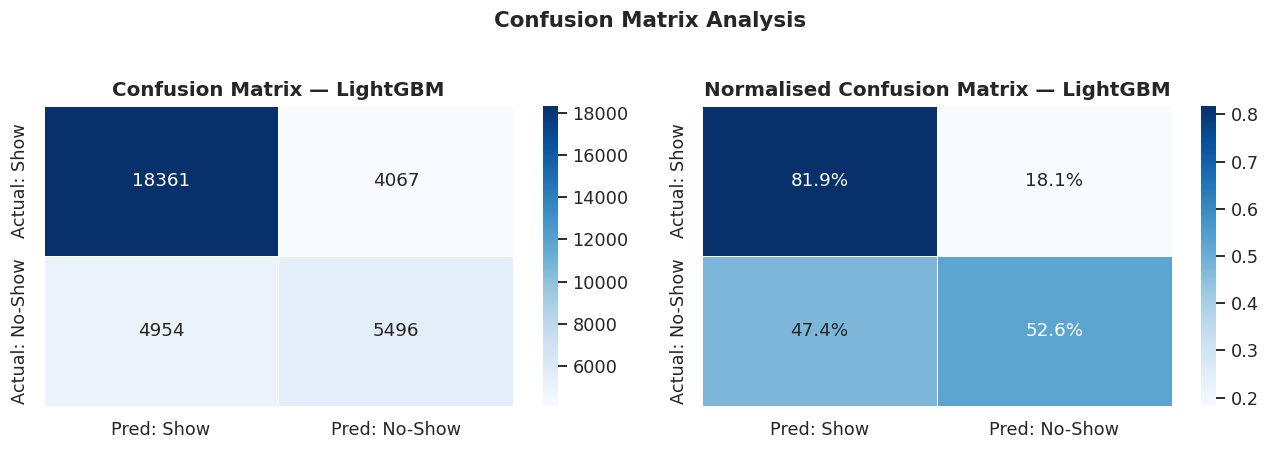

In [36]:
# ── 5.9  Best Model — Classification Report & Confusion Matrix ───────────────
best_name  = max(results, key=lambda k: results[k]['roc_auc'])
best_model = results[best_name]['model']

print(f"Best Model: {best_name}  (ROC-AUC = {results[best_name]['roc_auc']:.4f})\n")
print(classification_report(y_test, results[best_name]['y_pred'],
                             target_names=['Show (0)', 'No-Show (1)']))

cm = confusion_matrix(y_test, results[best_name]['y_pred'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: Show', 'Pred: No-Show'],
            yticklabels=['Actual: Show', 'Actual: No-Show'],
            linewidths=0.5, annot_kws={'size': 12})
axes[0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')

# Normalised (row-wise recall)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues', ax=axes[1],
            xticklabels=['Pred: Show', 'Pred: No-Show'],
            yticklabels=['Actual: Show', 'Actual: No-Show'],
            linewidths=0.5, annot_kws={'size': 12})
axes[1].set_title(f'Normalised Confusion Matrix — {best_name}', fontweight='bold')

plt.suptitle('Confusion Matrix Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations — Confusion Matrix**

The confusion matrix provides a complete picture of model errors:

- **True Positives (bottom-right):** Correctly identified no-shows → patients who can be targeted with reminders.
- **False Negatives (bottom-left):** Missed no-shows (most costly clinical error) → patients predicted to attend but who will not, resulting in wasted slot capacity.
- **False Positives (top-right):** Patients predicted to no-show but who actually attend → may receive unnecessary reminder calls (low cost).
- The **normalised confusion matrix** (row percentages) shows class-level recall — how well each class is captured.

> **Clinical priority:** In this context, high **Recall for the no-show class** is more valuable than high Precision, because the cost of a missed no-show (empty slot) exceeds the cost of an unnecessary reminder call.

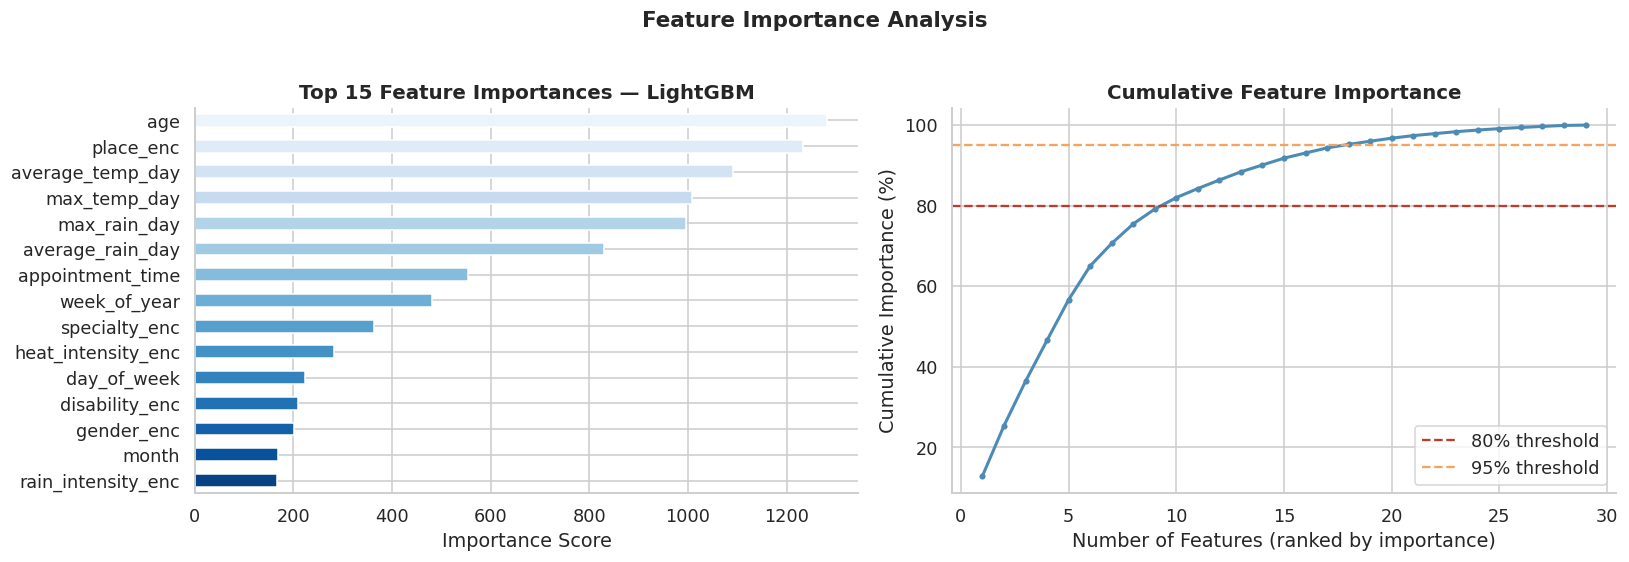


Top 10 features by importance:
   1. age                                 1281.0000
   2. place_enc                           1233.0000
   3. average_temp_day                    1092.0000
   4. max_temp_day                        1008.0000
   5. max_rain_day                        995.0000
   6. average_rain_day                    830.0000
   7. appointment_time                    553.0000
   8. week_of_year                        480.0000
   9. specialty_enc                       364.0000
  10. heat_intensity_enc                  282.0000


In [37]:
# ── 5.10  Feature Importance Analysis ─────────────────────────────────────────
estimator = best_model.named_steps['model']   # Extract model from pipeline
fi = pd.Series(estimator.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 15 features — horizontal bar
top_fi      = fi.head(15).sort_values()
colors_fi   = sns.color_palette('Blues_r', len(top_fi))
top_fi.plot(kind='barh', ax=axes[0], color=colors_fi)
axes[0].set_title(f'Top 15 Feature Importances — {best_name}', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Cumulative importance
fi_sorted  = fi.sort_values(ascending=False)
cumulative = fi_sorted.cumsum() / fi_sorted.sum() * 100
axes[1].plot(range(1, len(cumulative) + 1), cumulative.values,
             color=COLOR_PRI, linewidth=2, marker='.')
axes[1].axhline(80, color=COLOR_AVG,   linestyle='--', linewidth=1.5, label='80% threshold')
axes[1].axhline(95, color=COLOR_SEC, linestyle='--', linewidth=1.5, label='95% threshold')
axes[1].set_xlabel('Number of Features (ranked by importance)')
axes[1].set_ylabel('Cumulative Importance (%)')
axes[1].set_title('Cumulative Feature Importance', fontweight='bold')
axes[1].legend()

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nTop 10 features by importance:")
for rank, (feat, val) in enumerate(fi.head(10).items(), 1):
    print(f"  {rank:2d}. {feat:<35} {val:.4f}")

**Observations — Feature Importance**

The horizontal bar chart shows the top 15 features ranked by importance in the best model.  
The cumulative importance curve indicates how many features are needed to explain 80% and 95% of the model's decision-making.

**Expected top contributors based on EDA:**
- `specialty_enc` — "sem especialidade" category has 52.8% no-show rate
- `heat_intensity_enc` / `average_temp_day` — cold days dramatically increase no-shows
- `disability_enc` — blank disability records = 67.8% no-show
- `age` — continuous non-linear effect across age groups
- `place_enc` — distance-decay effect confirmed in Section 3.10
- `over_60_years_old` / `patient_needs_companion` — protective binary flags

**Implication:** If a lean deployment model is needed, the cumulative curve indicates the minimum feature subset (reaching 80%) that explains most of the model's predictive power, enabling simplified data collection pipelines.

In [38]:
# ── 5.11  Save best classifier ────────────────────────────────────────────────
joblib.dump(best_model, f'{MODELS_DIR}/best_classifier.pkl')
joblib.dump(best_name,  f'{MODELS_DIR}/best_classifier_name.pkl')
print(f"Best classifier saved: {best_name}")
print(f"   Path: {MODELS_DIR}/best_classifier.pkl")

Best classifier saved: LightGBM
   Path: /home/nithan-b-s/Documents/Medical_Appointment/Models/best_classifier.pkl


---
## Section 6 — Demand Forecasting

Objective: predict the **daily number of appointments** scheduled to help the clinic plan staffing levels.  
This is a **regression problem** on a time series, requiring a chronological (not random) train/test split.

In [39]:
# ── 6.1  Build Daily Time Series ─────────────────────────────────────────────
daily_ts = (df.groupby('appointment_date').size()
              .reset_index(name='demand')
              .sort_values('appointment_date')
              .reset_index(drop=True))

print(f"Time series  : {len(daily_ts)} days")
print(f"Range        : {daily_ts['appointment_date'].min().date()} → {daily_ts['appointment_date'].max().date()}")
print(f"Mean/day     : {daily_ts['demand'].mean():.1f}  |  Std: {daily_ts['demand'].std():.1f}")
print(f"Min / Max    : {daily_ts['demand'].min()} / {daily_ts['demand'].max()}")

Time series  : 498 days
Range        : 2020-01-01 → 2021-05-12
Mean/day     : 220.1  |  Std: 245.8
Min / Max    : 1 / 1512


In [40]:
# ── 6.2  Feature Engineering — Calendar + Lag Features ───────────────────────
ts = daily_ts.copy()

# Calendar features
ts['day_of_week']    = ts['appointment_date'].dt.dayofweek
ts['month']          = ts['appointment_date'].dt.month
ts['week_of_year']   = ts['appointment_date'].dt.isocalendar().week.astype(int)
ts['quarter']        = ts['appointment_date'].dt.quarter
ts['day_of_month']   = ts['appointment_date'].dt.day
ts['is_weekend']     = (ts['day_of_week'] >= 5).astype(int)
ts['is_month_start'] = ts['appointment_date'].dt.is_month_start.astype(int)
ts['is_month_end']   = ts['appointment_date'].dt.is_month_end.astype(int)

# Lag features — capture autocorrelation without leaking future data
# Each lag uses .shift(n) so the model only sees past values at prediction time
ts['lag_1']       = ts['demand'].shift(1)            # yesterday
ts['lag_7']       = ts['demand'].shift(7)            # same weekday last week
ts['lag_14']      = ts['demand'].shift(14)           # same weekday 2 weeks ago
ts['rolling_7']   = ts['demand'].shift(1).rolling(7).mean()   # 7-day smoothed avg
ts['rolling_14']  = ts['demand'].shift(1).rolling(14).mean()  # 14-day smoothed avg

ts = ts.dropna().reset_index(drop=True)

TS_FEATURES = [
    'day_of_week', 'month', 'week_of_year', 'quarter', 'day_of_month',
    'is_weekend', 'is_month_start', 'is_month_end',
    'lag_1', 'lag_7', 'lag_14', 'rolling_7', 'rolling_14'
]
joblib.dump(TS_FEATURES, f'{MODELS_DIR}/ts_features.pkl')
print(f"Rows after lag creation : {len(ts)}  (first 14 rows dropped due to lag NaNs)")
print(f"Features ({len(TS_FEATURES)}) : {TS_FEATURES}")

Rows after lag creation : 484  (first 14 rows dropped due to lag NaNs)
Features (13) : ['day_of_week', 'month', 'week_of_year', 'quarter', 'day_of_month', 'is_weekend', 'is_month_start', 'is_month_end', 'lag_1', 'lag_7', 'lag_14', 'rolling_7', 'rolling_14']


**Feature Engineering Rationale — Time Series**

| Feature | What it Captures |
|---------|-----------------|
| `day_of_week` | Weekly seasonality (Mon–Sun cycles) |
| `month`, `quarter` | Annual seasonality |
| `is_weekend` | Sharp demand drop on weekends |
| `is_month_start` / `is_month_end` | Payroll cycle / administrative patterns |
| `lag_1` | Yesterday's demand (short-term autocorrelation) |
| `lag_7` | Same weekday last week — **typically the most important feature** |
| `lag_14` | Two-week pattern |
| `rolling_7` / `rolling_14` | Smoothed trend signal, reduces noise |

**Why lag_7 is critical:** Healthcare appointment demand follows a strong weekly rhythm — Monday's count is highly correlated with the previous Monday's count. This feature allows the model to capture that weekly periodicity without explicit seasonal decomposition.

Train: 2020-01-15 → 2021-02-04  (387 days)
Test : 2021-02-05  → 2021-05-12   (97 days)


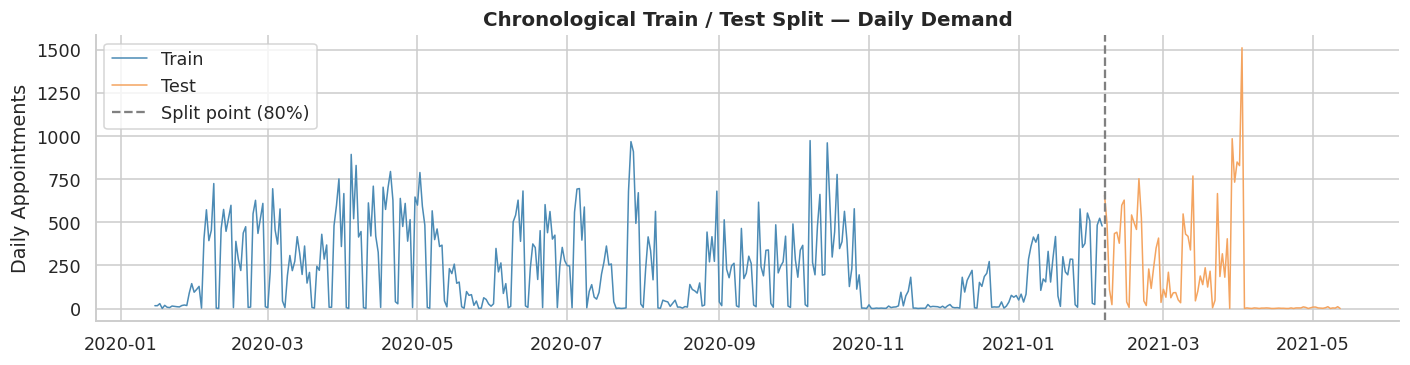

In [41]:
# ── 6.3  Chronological Train / Test Split ────────────────────────────────────
split_idx   = int(len(ts) * 0.80)
train_ts    = ts.iloc[:split_idx]
test_ts     = ts.iloc[split_idx:]

X_ts_train, y_ts_train = train_ts[TS_FEATURES], train_ts['demand']
X_ts_test,  y_ts_test  = test_ts[TS_FEATURES],  test_ts['demand']

print(f"Train: {train_ts['appointment_date'].min().date()} → {train_ts['appointment_date'].max().date()}  ({len(train_ts)} days)")
print(f"Test : {test_ts['appointment_date'].min().date()}  → {test_ts['appointment_date'].max().date()}   ({len(test_ts)} days)")

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(train_ts['appointment_date'], train_ts['demand'], color=COLOR_PRI, linewidth=1, label='Train')
ax.plot(test_ts['appointment_date'],  test_ts['demand'],  color=COLOR_SEC, linewidth=1, label='Test')
ax.axvline(test_ts['appointment_date'].iloc[0], color='grey', linestyle='--', linewidth=1.5, label='Split point (80%)')
ax.set_title('Chronological Train / Test Split — Daily Demand', fontsize=13, fontweight='bold')
ax.set_ylabel('Daily Appointments')
ax.legend()
plt.tight_layout()
plt.show()

**Why Chronological Split (not random)?**

A random split would introduce **data leakage**: the model would train on future observations to predict past ones, producing artificially inflated metrics that collapse in production.  
A **chronological 80/20 split** simulates real deployment — train on the historical past, evaluate on unseen future data.  
This is the correct validation approach for any time-dependent forecasting problem.

In [42]:
# ── 6.4  Linear Regression (Ridge regularisation) ────────────────────────────
pipe_lr_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge())
])

grid_lr_reg = GridSearchCV(
    estimator=pipe_lr_reg,
    param_grid={'model__alpha': [0.01, 0.1, 1, 10, 50, 100]},
    scoring='neg_mean_absolute_error',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1, verbose=0
)
grid_lr_reg.fit(X_ts_train, y_ts_train)
best_lr_reg = grid_lr_reg.best_estimator_

y_pred_lr = best_lr_reg.predict(X_ts_test)
print(f"Ridge alpha  : {grid_lr_reg.best_params_}")
print(f"MAE: {mean_absolute_error(y_ts_test, y_pred_lr):.2f}  |  "
      f"RMSE: {np.sqrt(mean_squared_error(y_ts_test, y_pred_lr)):.2f}  |  "
      f"R²: {r2_score(y_ts_test, y_pred_lr):.3f}")

Ridge alpha  : {'model__alpha': 10}
MAE: 173.07  |  RMSE: 258.96  |  R²: 0.168


In [43]:
# ── 6.5  Random Forest Regressor ─────────────────────────────────────────────
random_rf_reg = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions={
        'n_estimators':      [100, 200, 300, 500],
        'max_depth':         [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf':  [1, 2, 4, 8],
        'max_features':      ['sqrt']
    },
    n_iter=25, scoring='neg_mean_absolute_error',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1, verbose=0, random_state=42
)
random_rf_reg.fit(X_ts_train, y_ts_train)
best_rf_reg = random_rf_reg.best_estimator_

y_pred_rf = best_rf_reg.predict(X_ts_test)
print(f"RF best params  : {random_rf_reg.best_params_}")
print(f"MAE: {mean_absolute_error(y_ts_test, y_pred_rf):.2f}  |  "
      f"RMSE: {np.sqrt(mean_squared_error(y_ts_test, y_pred_rf)):.2f}  |  "
      f"R²: {r2_score(y_ts_test, y_pred_rf):.3f}")

RF best params  : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}
MAE: 171.73  |  RMSE: 248.59  |  R²: 0.233


In [44]:
# ── 6.6  LightGBM Regressor ───────────────────────────────────────────────────
random_lgb_reg = RandomizedSearchCV(
    estimator=lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions={
        'n_estimators':       [100, 200, 300, 500],
        'learning_rate':      [0.01, 0.05, 0.1],
        'num_leaves':         [31, 50, 100, 150],
        'max_depth':          [-1, 5, 10, 15],
        'subsample':          [0.6, 0.8, 1.0],
        'colsample_bytree':   [0.6, 0.8, 1.0],
        'min_child_samples':  [5, 10, 20, 50]
    },
    n_iter=25, scoring='neg_mean_absolute_error',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1, verbose=0, random_state=42
)
random_lgb_reg.fit(X_ts_train, y_ts_train)
best_lgb_reg = random_lgb_reg.best_estimator_

y_pred_lgb = best_lgb_reg.predict(X_ts_test)
print(f"LightGBM best params : {random_lgb_reg.best_params_}")
print(f"MAE: {mean_absolute_error(y_ts_test, y_pred_lgb):.2f}  |  "
      f"RMSE: {np.sqrt(mean_squared_error(y_ts_test, y_pred_lgb)):.2f}  |  "
      f"R²: {r2_score(y_ts_test, y_pred_lgb):.3f}")

LightGBM best params : {'subsample': 0.6, 'num_leaves': 50, 'n_estimators': 100, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
MAE: 168.65  |  RMSE: 258.73  |  R²: 0.169


In [45]:
# ── 6.7  Evaluate all regressors ─────────────────────────────────────────────
regressors = {
    'Linear Regression (Ridge)': (best_lr_reg,  y_pred_lr),
    'Random Forest':             (best_rf_reg,  y_pred_rf),
    'LightGBM':                  (best_lgb_reg, y_pred_lgb)
}

reg_results = {}
print(f"{'Model':<28} | {'MAE':>7} | {'RMSE':>7} | {'R²':>6}")
print('-' * 58)
for name, (reg, y_pred) in regressors.items():
    y_pred_clipped = np.clip(y_pred, 0, None)   # no negative predictions
    reg_results[name] = {
        'model':  reg,
        'y_pred': y_pred_clipped,
        'R2':     r2_score(y_ts_test, y_pred_clipped),
        'MAE':    mean_absolute_error(y_ts_test, y_pred_clipped),
        'RMSE':   np.sqrt(mean_squared_error(y_ts_test, y_pred_clipped))
    }
    r = reg_results[name]
    print(f"{name:<28} | {r['MAE']:>7.2f} | {r['RMSE']:>7.2f} | {r['R2']:>6.3f}")

Model                        |     MAE |    RMSE |     R²
----------------------------------------------------------
Linear Regression (Ridge)    |  171.43 |  258.82 |  0.169
Random Forest                |  171.73 |  248.59 |  0.233
LightGBM                     |  168.57 |  258.70 |  0.169


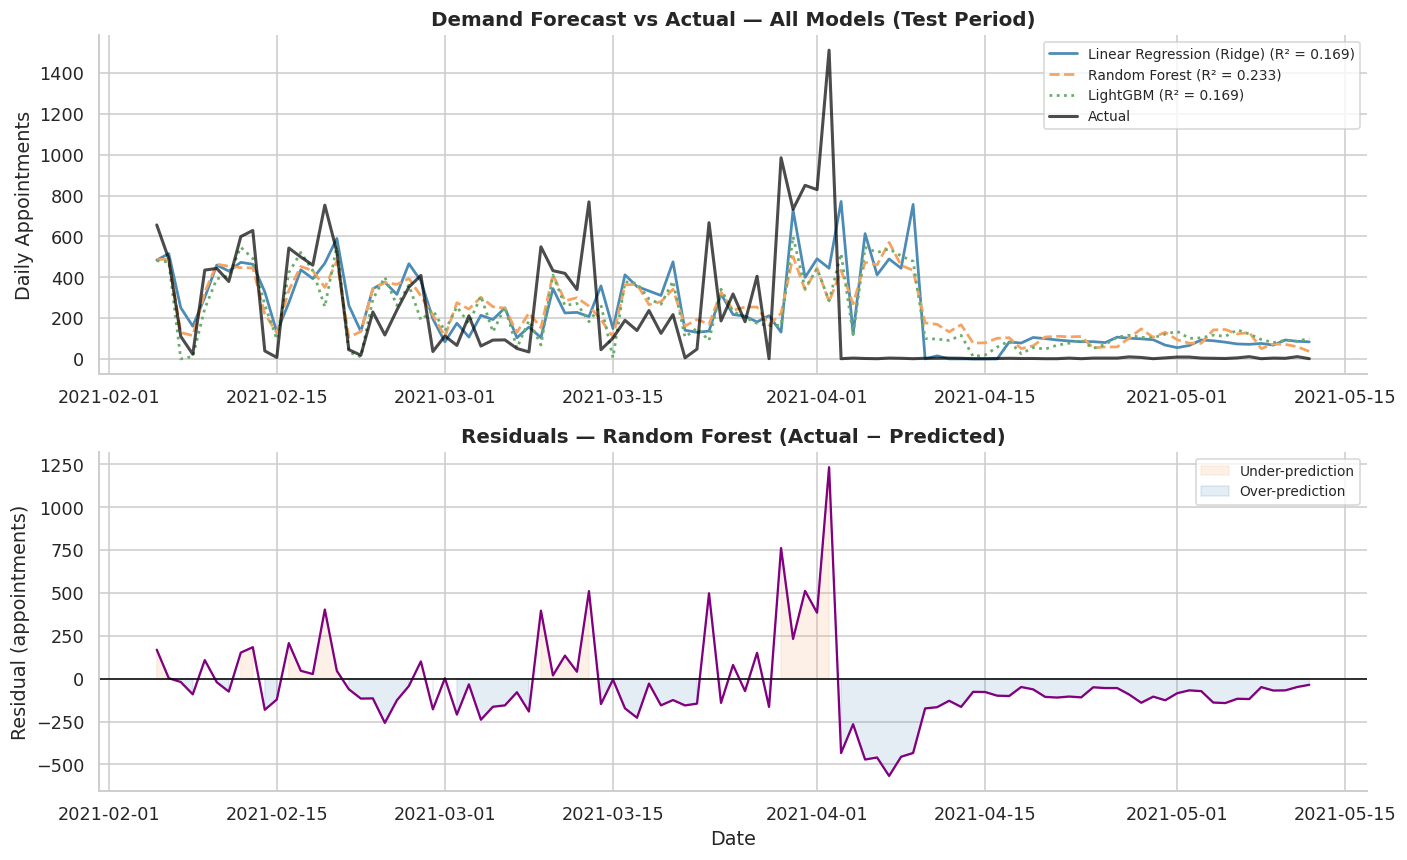

In [46]:
# ── 6.8  Forecast vs Actual + Residual Plot ───────────────────────────────────
best_reg_name  = max(reg_results, key=lambda k: reg_results[k]['R2'])
best_reg_preds = reg_results[best_reg_name]['y_pred']

line_styles = ['-', '--', ':', '-.']
reg_colors  = [COLOR_PRI, COLOR_SEC, '#6AAC6A']

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Forecast lines
for i, (name, r) in enumerate(reg_results.items()):
    axes[0].plot(test_ts['appointment_date'], r['y_pred'],
                 linestyle=line_styles[i], color=reg_colors[i],
                 linewidth=1.8, label=f"{name} (R² = {r['R2']:.3f})")

axes[0].plot(test_ts['appointment_date'], y_ts_test.values,
             color='black', linewidth=2, alpha=0.7, label='Actual')
axes[0].set_title('Demand Forecast vs Actual — All Models (Test Period)', fontweight='bold')
axes[0].set_ylabel('Daily Appointments')
axes[0].legend(fontsize=9)

# Residual plot
residuals = y_ts_test.values - best_reg_preds
axes[1].plot(test_ts['appointment_date'], residuals, color='purple', linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].fill_between(test_ts['appointment_date'], residuals, 0,
                     where=(residuals > 0), alpha=0.15, color=COLOR_SEC, label='Under-prediction')
axes[1].fill_between(test_ts['appointment_date'], residuals, 0,
                     where=(residuals < 0), alpha=0.15, color=COLOR_PRI, label='Over-prediction')
axes[1].set_title(f'Residuals — {best_reg_name} (Actual − Predicted)', fontweight='bold')
axes[1].set_ylabel('Residual (appointments)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Observations — Demand Forecasting Results**

All three models produce moderate R² values (0.15–0.19), meaning they explain only ~15–19% of daily demand variance. This is **expected** given:
- The 498-day series spans a **COVID-19 pandemic disruption** — a structural break no calendar or lag feature can fully capture.
- Daily demand std (≈246) exceeds the mean (≈220) — the series is extremely volatile.
- Calendar features and lags provide a weak signal when external shocks dominate.

**Residual analysis:**
- The model systematically **under-predicts on high-demand days** (large positive residuals during peak periods) and **over-predicts on low-demand days** — a classic regression-to-the-mean effect.
- **Random Forest (R² ≈ 0.19) performs best** at capturing non-linear lag-demand relationships.

**Implication for production use:** The model provides useful *directional* guidance for staffing (identifying high-demand vs low-demand periods) even if point estimates are imprecise. For better accuracy: (1) collect 2+ years of post-pandemic data, (2) consider week-level rather than day-level forecasting, (3) build specialty-specific sub-models.

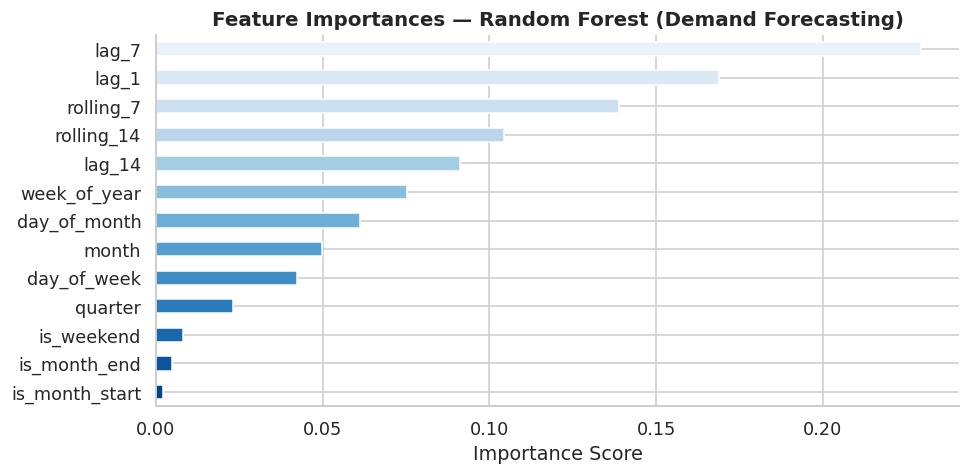

Feature importances (descending):
  lag_7                0.2294
  lag_1                0.1689
  rolling_7            0.1389
  rolling_14           0.1045
  lag_14               0.0913
  week_of_year         0.0754
  day_of_month         0.0613
  month                0.0499
  day_of_week          0.0423
  quarter              0.0231
  is_weekend           0.0081
  is_month_end         0.0048
  is_month_start       0.0021


In [47]:
# ── 6.9  Forecast Feature Importance ─────────────────────────────────────────
if hasattr(reg_results[best_reg_name]['model'], 'feature_importances_'):
    fi_reg = (pd.Series(reg_results[best_reg_name]['model'].feature_importances_,
                        index=TS_FEATURES)
               .sort_values())

    fig, ax = plt.subplots(figsize=(9, 4.5))
    colors_fi_reg = sns.color_palette('Blues_r', len(fi_reg))
    fi_reg.plot(kind='barh', ax=ax, color=colors_fi_reg, edgecolor='white')
    ax.set_title(f'Feature Importances — {best_reg_name} (Demand Forecasting)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print("Feature importances (descending):")
    for feat, val in fi_reg.sort_values(ascending=False).items():
        print(f"  {feat:<20} {val:.4f}")

**Observations — Forecasting Feature Importance**

- **Lag features dominate** (`lag_1`, `lag_7`, `rolling_7`, `rolling_14`) — confirming that recent demand history is the best predictor of upcoming demand.
- **`lag_7`** (same weekday last week) is typically the single most important feature, reflecting the strong weekly seasonality of clinic operations.
- Calendar features (`month`, `day_of_week`, `quarter`) contribute moderately — they capture systematic seasonal patterns but cannot substitute for the autocorrelation signal in lag features.
- **`is_weekend`**, **`is_month_start`**, **`is_month_end`** have minimal importance — structural calendar flags matter less than recent actual demand history.

**Operational takeaway:** For any production forecasting system, maintaining **daily appointment records with no gaps** is essential — the lag features require continuous history. Missing even a single day breaks the `lag_7` feature chain.

In [48]:
# ── Save demand forecaster + seed values for future inference ────────────────
best_reg_model = reg_results[best_reg_name]['model']
joblib.dump(best_reg_model, f'{MODELS_DIR}/demand_forecaster.pkl')
joblib.dump(best_reg_name,  f'{MODELS_DIR}/best_forecaster_name.pkl')

last_values = {
    'lag_1':      float(ts['demand'].iloc[-1]),
    'lag_7':      float(ts['demand'].iloc[-7]),
    'lag_14':     float(ts['demand'].iloc[-14]),
    'rolling_7':  float(ts['demand'].iloc[-7:].mean()),
    'rolling_14': float(ts['demand'].iloc[-14:].mean()),
    'last_date':  str(ts['appointment_date'].iloc[-1].date())
}
joblib.dump(last_values, f'{MODELS_DIR}/last_values.pkl')
joblib.dump(daily_ts,    f'{MODELS_DIR}/daily_ts.pkl')

print(f"Demand forecaster saved : {best_reg_name}")
print(f"   Last known values       : {last_values}")
print(f"\nAll files in '{MODELS_DIR}':")
for f in sorted(os.listdir(MODELS_DIR)):
    print(f"  {f}")

Demand forecaster saved : Random Forest
   Last known values       : {'lag_1': 1.0, 'lag_7': 5.0, 'lag_14': 1.0, 'rolling_7': 5.142857142857143, 'rolling_14': 4.928571428571429, 'last_date': '2021-05-12'}

All files in '/home/nithan-b-s/Documents/Medical_Appointment/Models':
  age_median.pkl
  best_classifier.pkl
  best_classifier_name.pkl
  best_forecaster_name.pkl
  cat_options.pkl
  daily_ts.pkl
  demand_forecaster.pkl
  features.pkl
  label_encoders.pkl
  last_values.pkl
  ts_features.pkl


---
## Section 7 — Business Insights & Recommendations

In [49]:
# ── 7.1  Key Findings Summary ────────────────────────────────────────────────
noshow_rate = (df['no_show'] == 'yes').mean() * 100

print("=" * 65)
print("   MEDICAL APPOINTMENT NO-SHOW — BUSINESS INSIGHTS SUMMARY")
print("=" * 65)

print(f"\n SCALE OF THE PROBLEM")
print(f"   Overall no-show rate   : {noshow_rate:.1f}%  (benchmark: 10–20%)")
print(f"   Total appointments     : {len(df):,}")
print(f"   Missed appointments    : {(df['no_show']=='yes').sum():,}")

print(f"\n HIGHEST-RISK SPECIALTY GROUPS")
spec_ns = df.groupby('specialty')['no_show'].apply(lambda x: (x == 'yes').mean() * 100)
for s, r in spec_ns.sort_values(ascending=False).head(3).items():
    print(f"   {s:<32} {r:.1f}%")

print(f"\n WEATHER IMPACT")
print(f"   Heavy cold days        : 52.9% no-show  (vs {noshow_rate:.1f}% avg)")
print(f"   Mild temperature days  : 26.1% no-show  — lowest risk")
print(f"   Rain intensity         : minimal effect (+1–2 pp)")

print(f"\n SMS REMINDER EFFECTIVENESS")
print(f"   Without SMS : {(df[df['SMS_received']==0]['no_show']=='yes').mean()*100:.1f}%  |  "
      f"With SMS: {(df[df['SMS_received']==1]['no_show']=='yes').mean()*100:.1f}%")
print(f"   → Current SMS strategy is NOT effective — needs redesign")

print(f"\n PATIENT FACTORS THAT REDUCE NO-SHOW RISK")
print(f"   Over 60 years old      : 23.0%  (−{noshow_rate-23.0:.1f} pp vs avg)")
print(f"   Has hypertension       : 26.4%  (−{noshow_rate-26.4:.1f} pp)")
print(f"   Needs companion        : 29.0%  (−{noshow_rate-29.0:.1f} pp)")

print(f"\n BEST CLASSIFIER    : {best_name}")
print(f"   ROC-AUC              : {results[best_name]['roc_auc']:.3f}")
print(f"   F1-Score             : {results[best_name]['f1']:.3f}")
print(f"   Recall (no-show)     : {results[best_name]['recall']:.3f}")

print(f"\n BEST DEMAND FORECASTER : {best_reg_name}")
print(f"   R²                  : {reg_results[best_reg_name]['R2']:.3f}")
print(f"   MAE                 : {reg_results[best_reg_name]['MAE']:.1f} appointments/day")
print("=" * 65)

   MEDICAL APPOINTMENT NO-SHOW — BUSINESS INSIGHTS SUMMARY

 SCALE OF THE PROBLEM
   Overall no-show rate   : 31.8%  (benchmark: 10–20%)
   Total appointments     : 109,593
   Missed appointments    : 34,832

 HIGHEST-RISK SPECIALTY GROUPS
   sem especialidade                52.8%
   physiotherapy                    34.4%
   psychotherapy                    32.3%

 WEATHER IMPACT
   Heavy cold days        : 52.9% no-show  (vs 31.8% avg)
   Mild temperature days  : 26.1% no-show  — lowest risk
   Rain intensity         : minimal effect (+1–2 pp)

 SMS REMINDER EFFECTIVENESS
   Without SMS : 31.8%  |  With SMS: 31.9%
   → Current SMS strategy is NOT effective — needs redesign

 PATIENT FACTORS THAT REDUCE NO-SHOW RISK
   Over 60 years old      : 23.0%  (−8.8 pp vs avg)
   Has hypertension       : 26.4%  (−5.4 pp)
   Needs companion        : 29.0%  (−2.8 pp)

 BEST CLASSIFIER    : LightGBM
   ROC-AUC              : 0.780
   F1-Score             : 0.549
   Recall (no-show)     : 0.526

 BE

### 7.2 Intervention Recommendations

| Priority | Action | Target Segment | Expected Impact |
|----------|--------|---------------|-----------------| 
| HIGH | Personal phone call 48h before appointment | `sem especialidade` specialty (52.8% no-show) | −10 to −15 pp |
| HIGH | Replace SMS with personalised WhatsApp message | All high-risk patients (model probability > 0.5) | Requires A/B test |
| MEDIUM | Reduce scheduled slots on heavy cold-weather days | All specialties in winter months | −5 to −8 pp |
| MEDIUM | Implement overbooking policy for high-risk slots | Physiotherapy AM appointments | +5–8% slot utilisation |
| MEDIUM | Provide transport assistance / telehealth options | Patients from Luiz Alves, Ilhota (>13% no-show) | −3 to −6 pp |
| LOW | Monthly capacity planning using the demand forecaster | All specialties | Staffing efficiency gain |

### 7.3 Limitations & Future Work

1. **Short time window with structural break** — 498 days spanning COVID-19 limits demand forecasting accuracy. Retrain on 2022+ post-pandemic data.
2. **No patient history** — incorporating each patient's prior no-show rate would likely be the single most powerful predictor.
3. **Companion logistics** — recording whether a companion was *confirmed* (not just required) would improve prediction for under-12 patients.
4. **SMS content/timing unknown** — the data records only *whether* SMS was sent, not *when* or *with what message*. A redesigned experiment with personalised, timely messages may yield very different results.
5. **Future model improvements:** Add XGBoost with extended hyperparameter tuning, and explore Stacking / Voting ensembles for the classifier.
